# Main Figure 3

This notebook is dedicated to produce the content of [Pepe, Mariani et al. 2026](https://www.biorxiv.org/content/10.64898/2026.02.05.704055v1.full) figure 3. It relies on the ["Structural and dynamic embedding of the mouse functional connectome revealed by functional ultrasound imaging (fUSI)"](10.5281/zenodo.18486492) dataset publically available on Zenodo. Absolute paths MUST be adapted to your local environment. The structure of the notebook is as follow:

- Import of packages
- Local helper functions
- Definition of general parameters
- 4 sections associated to each subpannel of the figure and quality checks addons
    - `**Compute FC and SC**` is divided in two sections and processed fUSI data to generate a population FC matrix and the Allen Brain Atlas (ABA) publically available data to generate a SC matrix. Additional subsection standardise the matrix with relevant kernals to maximize gaussianity of the data for interpretability of the SC/FC relationship.
    - `**Network Level SFC**` estimates correlation between SC and FC at the network level (all edges distribution similarity)
    - `**Parcel Level SFC**`  
    - `**ICA**` gets a collection of `.nii.gz` 4D time series and estimate Independent Component based on dictionary learning methods as detailed in [nilearn documentation](https://nilearn.github.io/stable/auto_examples/03_connectivity/plot_compare_decomposition.html).

In [1]:
import re

import numpy as np
import colorcet as cc
import nibabel as nib
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as stats

from pathlib import Path
from tqdm import tqdm
from rastermap import Rastermap

from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

from matplotlib.colorbar import ColorbarBase
from nilearn.masking import apply_mask, unmask
from nilearn.image import math_img, resample_img
from nilearn.maskers import NiftiLabelsMasker
from matplotlib.patches import Polygon
from scipy.ndimage import binary_fill_holes, zoom, gaussian_filter, binary_dilation, binary_erosion
from scipy.stats import gaussian_kde

import matplotlib.patches as patches

from scipy.stats import gaussian_kde

/media/DATA/jmariani/4_utils/miniconda3/envs/JCmri/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# Helper functions

In [2]:
def smooth_high_res_cluster(
    img_2_display,
    sigma = 2.,
    th = 0.5
):

    """
    Smooth and regularize labeled clusters in a segmentation image.

    Each non-zero label is processed independently by converting it to a
    binary mask, applying Gaussian smoothing, thresholding the smoothed mask,
    and performing a binary erosion. The resulting masks are combined into a
    new labeled image while preserving the original label values.

    Parameters
    ----------
    img_2_display : ndarray
        Input labeled image. Background voxels should be labeled as 0, while
        each connected region or cluster is identified by a unique positive
        integer.
    sigma : float, optional
        Standard deviation of the Gaussian kernel used to smooth each binary
        mask before thresholding. Default is 2.0.
    th : float, optional
        Threshold applied to the smoothed binary mask. Voxels with values
        greater than `th` are retained. Default is 0.5.

    Returns
    -------
    ndarray
        Labeled image of the same shape as `img_2_display` containing the
        smoothed and eroded clusters. Background voxels remain equal to 0.

    Notes
    -----
    - Each label is processed independently, preventing neighboring labels
      from mixing during smoothing.
    - A binary erosion of 5 iterations is applied after thresholding to
      remove small protrusions and regularize cluster boundaries.
    - If two processed clusters overlap after smoothing, the label processed
      later in the iteration overwrites the previous one.
    """
    
    img_out = np.zeros(img_2_display.shape)
    
    for k in np.unique(img_2_display):
        
        if k !=0 :
            
            mask = 1.*(img_2_display == k)
            mask = gaussian_filter(mask, sigma)>th
            mask = binary_erosion(mask, iterations=5)
            img_out[mask>0] = k

    return img_out

#function for correlation plot SC-FC axes

def density_profile(xs, data, bw=0.3):

    """
    Estimate a one-dimensional probability density using Gaussian kernel
    density estimation (KDE).

    Parameters
    ----------
    xs : array_like
        Coordinates at which to evaluate the estimated probability density.
    data : array_like
        One-dimensional sample from which the kernel density estimate is
        computed.
    bw : float or str or callable, optional
        Bandwidth method passed to `scipy.stats.gaussian_kde` via the
        `bw_method` argument. A scalar acts as a bandwidth scaling factor.
        Default is 0.3.

    Returns
    -------
    ndarray
        Estimated probability density evaluated at `xs`.

    Notes
    -----
    This function is a convenience wrapper around
    `scipy.stats.gaussian_kde`.
    """
    
    kde = gaussian_kde(data, bw_method=bw)
    
    return kde(xs)

def custom_join_plot(
    x,
    y,
    dpi=200,
    figsize=(5, 5),
    nb_ticks=5,
    fill_alpha=0.20,
    n_bins=20,
    precision = 10,
    fill_c = 'C1', 
    edge_c = 'darkorange', 
    scatter_fc = (1.0, 0.55, 0.0, 0.1),
    scatter_ec = 'darkorange',
    std_fc = 'C3'
):

    """
    Create a joint scatter plot with linear regression and marginal densities.

    The main panel displays the relationship between `x` and `y` as a scatter
    plot together with an ordinary least-squares regression line. A local
    residual standard-deviation band is estimated by dividing the x-axis into
    bins and computing the spread of the residuals within each bin. Gaussian
    kernel density estimates of `x` and `y` are shown in the top and right
    marginal panels, respectively.

    Parameters
    ----------
    x : array_like
        One-dimensional array containing the predictor values.
    y : array_like
        One-dimensional array containing the response values. Must have the
        same length as `x`.
    dpi : int, optional
        Resolution of the created figure in dots per inch. Default is 200.
    figsize : tuple of float, optional
        Figure dimensions in inches, given as `(width, height)`.
        Default is `(5, 5)`.
    nb_ticks : int, optional
        Intended number of ticks on each axis of the main plot. Note that the
        current implementation overrides this value internally and uses three
        ticks. Default is 5.
    fill_alpha : float, optional
        Opacity of the local residual standard-deviation band. Default is 0.20.
    n_bins : int, optional
        Number of bin edges used to estimate the local residual variability
        along the x-axis. The resulting band contains `n_bins - 1` local
        estimates. Default is 20.
    precision : float, optional
        Scaling factor used when calculating rounded axis limits and tick
        positions. Larger values generally produce finer tick spacing.
        Default is 10.
    fill_c : color, optional
        Matplotlib-compatible color used to fill the marginal density plots.
        Default is `'C1'`.
    edge_c : color, optional
        Matplotlib-compatible color used for the marginal density outlines.
        Default is `'darkorange'`.
    scatter_fc : color, optional
        Matplotlib-compatible face color of the scatter points. It may include
        an alpha component when specified as an RGBA tuple.
        Default is `(1.0, 0.55, 0.0, 0.1)`.
    scatter_ec : color, optional
        Matplotlib-compatible edge color of the scatter points.
        Default is `'darkorange'`.
    std_fc : color, optional
        Matplotlib-compatible color of the local residual standard-deviation
        band. Default is `'C3'`.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure containing the joint plot.
    ax : numpy.ndarray of matplotlib.axes.Axes
        A 2-by-2 array of axes. The scatter and regression plot is located at
        `ax[1, 0]`, the x-density plot at `ax[0, 0]`, and the y-density plot at
        `ax[1, 1]`.

    Notes
    -----
    The regression is computed with `scipy.stats.linregress`.

    For each x-axis bin, the local variability is estimated from the residuals
    around the global regression line. Bins containing one observation use the
    absolute residual, while empty bins reuse the preceding estimate or zero
    when no preceding estimate exists.

    The marginal distributions are estimated using `density_profile` with a
    fixed bandwidth of 0.15.

    NaN or infinite values should be removed before calling this function.
    """
    
    xylim = [x.min(), x.max(), y.min(), y.max()]
    xs = np.linspace(xylim[0], xylim[1], 200)

    pearsonr = stats.linregress(x, y)
    ys = pearsonr.intercept + pearsonr.slope * xs

    # p-value formatting
    if pearsonr.pvalue > 0.01:
        p_val = f'p = {pearsonr.pvalue:.2f}'
    elif pearsonr.pvalue > 0.001:
        p_val = f'p < 0.01'
    elif pearsonr.pvalue > 0.0001:
        p_val = f'p < 0.001'
    elif np.log10(pearsonr.pvalue) > -10:
        p_val = f'p < $10^{{{np.ceil(np.log10(pearsonr.pvalue))}}}$'
    else:
        p_val = f'p < $10^{{-10}}$'

    # --- Local ±1 std around regression line ---
    bin_edges = np.linspace(xylim[0], xylim[1], n_bins)
    local_std = []

    for start, end in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (x > start) & (x <= end)
        x_bin = x[mask]
        y_bin = y[mask]
        if len(y_bin) > 1:
            y_pred = pearsonr.intercept + pearsonr.slope * x_bin
            residuals = y_bin - y_pred
            std_val = np.sqrt((residuals**2).sum() / (len(y_bin) - 1))
        elif len(y_bin) == 1:
            y_pred = pearsonr.intercept + pearsonr.slope * x_bin
            std_val = np.abs(y_bin - y_pred)[0]
        else:
            std_val = local_std[-1] if local_std else 0
        local_std.append(std_val)

    xci = (bin_edges[:-1] + bin_edges[1:]) / 2
    yci = pearsonr.intercept + pearsonr.slope * xci

    #if smooth_std:
     #   local_std = gaussian_filter1d(local_std, sigma=1)

    # --- Plotting ---
    fig, ax = plt.subplots(2, 2, figsize=figsize, dpi=dpi,
                           gridspec_kw={'height_ratios': [1.5, 7], 'width_ratios': [7, 1.5]})

    ax[0, 0].axis('off')
    ax[0, 1].axis('off')
    ax[1, 1].axis('off')

    # Top density
    top_density = density_profile(xs, x, bw=0.15)
    ax[0, 0].fill_between(xs, top_density, 0, facecolor=fill_c, edgecolor='none', alpha=0.6)
    ax[0, 0].plot(xs, top_density, color=edge_c, linewidth=2.5)
    ax[0, 0].set_xlim(x.min(), x.max())
    ax[0, 0].set_ylim(0, top_density.max() * 1.1)

    # Right density
    ys_density = np.linspace(y.min(), y.max(), 200)
    right_density = density_profile(ys_density, y, bw=0.15)
    ax[1, 1].fill_betweenx(ys_density, 0, right_density, facecolor=fill_c, edgecolor='none', alpha=0.6)
    ax[1, 1].plot(right_density, ys_density, color=edge_c, linewidth=2.5)
    ax[1, 1].set_ylim(y.min(), y.max())
    ax[1, 1].set_xlim(0, right_density.max() * 1.1)

    # Local std fill
    ax[1, 0].fill_between(
        xci,
        yci - local_std,
        yci + local_std,
        color=std_fc,
        alpha=fill_alpha,
        edgecolor=None,
        zorder=5
    )

    # Polygon outline 
    std_outline = Polygon(
        np.stack([
            np.concatenate([xci, np.flip(xci)]),
            np.concatenate([yci + local_std, np.flip(yci - local_std)])
        ]).T,
        fill=False,
        color=std_fc,
        linewidth=1.5,
        alpha=0,
        zorder=6
    )
    ax[1, 0].add_patch(std_outline)

    # Scatter
    ax[1, 0].scatter(
        x,
        y,
        s=180,
        facecolor=scatter_fc,
        edgecolor=scatter_ec,
        linewidth=0.7,
        zorder=3
    )

    # Regression line
    ax[1, 0].plot(xs, ys, c='k', linewidth=5, zorder=4)

    # Axis ticks
    [xm, xM, ym, yM] = ax[1, 0].axis()

    # Set number of ticks
    nb_ticks = 3  # or whatever number you want
    
    local_xM = ((((np.floor(xM*precision)//(nb_ticks-1)))+1)*(nb_ticks-1)/precision)
    local_xm = ((((np.ceil(xm*precision)//(nb_ticks-1)))+1)*(nb_ticks-1)/precision)
    xticks = [np.round(v, 2) for v in (local_xm + np.arange(nb_ticks) * (local_xM-local_xm)/(nb_ticks-1))]

    local_yM = ((((np.floor(yM*precision)//(nb_ticks-1)))+1)*(nb_ticks-1)/precision)
    local_ym = ((((np.ceil(ym*precision)//(nb_ticks-1)))+1)*(nb_ticks-1)/precision)
    yticks = [np.round(v, 2) for v in (local_ym + np.arange(nb_ticks) * (local_yM-local_ym)/(nb_ticks-1))]
    
    # Apply ticks
    ax[1, 0].set_xticks(xticks)
    ax[1, 0].set_yticks(yticks)


    ax[0, 0].set_xlim(xm, xM)
    ax[1, 1].set_ylim(ym, yM)

    # Styling
    for spine_name, spine in ax[1, 0].spines.items():
        spine.set_visible(spine_name in ['bottom', 'left'])
        if spine_name in ['bottom', 'left']:
            spine.set_linewidth(3)
    ax[1, 0].tick_params(width=3, length=5, labelsize=26)

        # Text annotation (r only, no p-value)
    ax[1, 0].text(0.25 * xM, 0.9 * yM, f'r = {pearsonr.rvalue:.2f}',
                  ha='center', fontsize=26)

    plt.tight_layout()

    return fig, ax

def compute_correlation_matrix(
    file_name,
    roi_list
):

    """
    Compute the Pearson correlation matrix between ROI time series extracted
    from a 4D neuroimaging dataset.

    For each region of interest (ROI) in `roi_list`, the corresponding mean
    time series is extracted from the input image using `extract_signal`.
    Pairwise Pearson correlation coefficients are then computed between all
    extracted time series to produce a symmetric correlation matrix.

    Parameters
    ----------
    file_name : str or pathlib.Path
        Path to the input 4D neuroimaging file readable by NiBabel (e.g.,
        NIfTI image).
    roi_list : sequence
        Sequence of ROI definitions accepted by `extract_signal`. Each element
        should specify one region from which a representative time series can
        be extracted.

    Returns
    -------
    ndarray of shape (N, N)
        Symmetric Pearson correlation matrix, where `N = len(roi_list)`.
        Element `(i, j)` contains the Pearson correlation coefficient between
        the time series extracted from the *i*-th and *j*-th ROI. The diagonal
        contains ones.

    Notes
    -----
    - ROI time series are extracted in parallel using `joblib.Parallel`.
    - Correlations are computed using `numpy.corrcoef`.
    """
    
    nb_parcels = len(roi_list)
    
    # loads image
    
    img = nib.load(file_name)
    
    # extracts signals
        
    with tqdm_joblib(desc=f"extracting signals...", total=len(roi_list)) as progress_bar:

        signals = Parallel(n_jobs=18)(delayed(extract_signal)(
            img,
            roi
        ) for roi in roi_list)
        
    cor_mat = np.zeros((nb_parcels, nb_parcels))
        
    for i in range(nb_parcels):
        for j in range(nb_parcels):
            
            cor_mat[i,j] = np.corrcoef(signals[i], signals[j])[0,1]
            
    return cor_mat

def extract_signal(img, roi):
    
    """
    Extract and standardize the mean time series from a region of interest.

    The function computes the average signal across all voxels within the
    specified ROI for each time point and standardizes the resulting time
    series to zero mean and unit variance.

    Parameters
    ----------
    img : nibabel.spatialimages.SpatialImage
        Input 4D functional image from which to extract the signal.
    roi : nibabel.spatialimages.SpatialImage or str or pathlib.Path
        Binary mask defining the region of interest. Non-zero voxels are
        included in the signal extraction.

    Returns
    -------
    ndarray of shape (n_samples,)
        Standardized mean time series extracted from the ROI.

    Notes
    -----
    Signal extraction is performed using ``nilearn.masking.apply_mask``.
    The extracted time series is standardized by subtracting its mean and
    dividing by its standard deviation. If the extracted signal has zero
    variance, the returned values will be NaN due to division by zero.
    """
    
    signal = apply_mask(img, roi).mean(1)
    signal = (signal-signal.mean())/signal.std()
    
    return signal

def from_mat_2_vect(mat):

    """
    Vectorize the lower triangular part of a square matrix.

    The function extracts the elements of the strictly lower triangular
    portion of the input matrix (excluding the diagonal) and returns them as
    a one-dimensional array in row-major order. This representation is
    commonly used to store symmetric matrices, such as correlation or
    connectivity matrices, without redundant entries.

    Parameters
    ----------
    mat : ndarray of shape (n, n)
        Square input matrix.

    Returns
    -------
    ndarray of shape (n * (n - 1) // 2,)
        One-dimensional array containing the elements of the strictly lower
        triangular part of ``mat``, ordered row by row.

    Notes
    -----
    The diagonal elements are excluded from the output. For symmetric
    matrices, the returned vector contains all unique off-diagonal entries.
    """
    
    nb_parcels = mat.shape[0]
    
    vect = mat[np.tril(np.ones((nb_parcels, nb_parcels)), -1).astype(bool)]
    
    return vect

def from_vector_2_map(vector, parcel_img):

    """
    Generate a parcellated image from a vector of parcel-wise values.

    Each element of the input vector is assigned to the corresponding parcel
    in the parcellation image. Parcel labels are assumed to be consecutive
    positive integers starting at 1, such that the first element of
    ``vector`` is assigned to voxels labeled 1, the second element to voxels
    labeled 2, and so on. Voxels with a label of 0 remain equal to zero in
    the output image.

    Parameters
    ----------
    vector : array-like of shape (n_parcels,)
        Parcel-wise values to map onto the parcellation image.
    parcel_img : nibabel.spatialimages.SpatialImage
        Parcellation image whose voxel values define parcel labels. Labels
        are expected to be consecutive integers ranging from 1 to
        ``len(vector)``.

    Returns
    -------
    nibabel.nifti1.Nifti1Image
        NIfTI image in which each parcel is assigned the corresponding value
        from ``vector``. The output image inherits the affine transformation
        from ``parcel_img``.

    Notes
    -----
    The function assumes that parcel labels are consecutive and begin at 1.
    Labels greater than ``len(vector)`` are ignored, while voxels labeled 0
    are treated as background and retain a value of zero in the output image.
    """
    
    # Generates map from a vector and parcel image

    output_map = np.zeros(parcel_img.shape)

    for idx, value in enumerate(vector):

        output_map[parcel_img.get_fdata() == idx+1] = value
    
    return nib.Nifti1Image(
        output_map,
        affine = parcel_img.affine
    )

def fill_holes_sw(img_2_display):
    
    """
    Fill holes and smooth labeled regions in a segmentation image.

    Each non-zero label is processed independently by applying a sequence of
    binary morphological operations consisting of dilation, hole filling, and
    erosion. The processed binary mask is then assigned its original label in
    the output image. Background voxels (label 0) are left unchanged.

    Parameters
    ----------
    img_2_display : ndarray
        Two-dimensional or three-dimensional labeled image. Each unique
        non-zero value is interpreted as an independent region.

    Returns
    -------
    ndarray
        Labeled image with holes filled and region boundaries smoothed.
        The output has the same shape as the input.

    Notes
    -----
    For each label, the following operations are applied in sequence:

    1. Binary dilation.
    2. Binary hole filling.
    3. Binary erosion.

    This sequence is equivalent to a binary closing followed by hole filling
    and is useful for removing small holes and smoothing irregular boundaries
    while approximately preserving the original object size.

    Labels are processed independently, so adjacent labeled regions may
    compete for voxels if the dilation step causes them to overlap.
    The last processed label takes precedence in overlapping regions.
    """
    
    img_out = np.zeros(img_2_display.shape)
    
    for k in np.unique(img_2_display):
        
        if k !=0 :
            
            mask = (img_2_display == k).astype(float)
            mask = binary_erosion(binary_fill_holes(binary_dilation(mask)))
            img_out[mask>0] = k
            
    return img_out

# General Parameters

Parameters that apply for the entire notebook.

In [3]:
########################## Display parameter

# fUSI number of slices
nb_col = 4

########################## Parameter images

# Allen template 
template_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/fusi/volume/templates/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-110umx100umx100um_pose-vol_feature.nii.gz')
template_img = nib.load(template_name)

# Allen mask
mask_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/fusi/volume/templates/source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-vol_feature.nii.gz')
mask_img = nib.load(mask_name)

################ Template high resolution

template_hr_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/fusi/volume/templates/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-25umx25umx25um_pose-vol_feature.nii.gz')
template_hr_img = nib.load(template_hr_name)

[X,Y,Z] = template_hr_img.shape
template_vmin = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].min()
template_vmax = template_hr_img.get_fdata()[int(X/2)-50:int(X/2)+50,int(Z/2)-50:int(Z/2)+50].max()

################ Parcellation

parcellation_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/fusi/volume/parcellations/source-gozzilab_space-fUSI100_desc-parcellationUnilateralDefaultN54_res-100umx100umx100um_pose-vol_feature.nii.gz')
parcellation = nib.load(parcellation_name)
acro_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/fusi/volume/parcellations/source-gozzilab_space-fUSI100_desc-parcellationUnilateralDefaultN54_res-100umx100umx100um_pose-vol_feature.csv')
acro_df = pd.read_csv(acro_name)

# extracts features from the parcellation

nb_parcels = len(acro_df)

roi_list = []
roi_dict = {
    'acro':[],
    'id':[],
    'hemisphere':[],
    'AllenNetwork':[],
    'LudoNetwork':[]
}

for i,roi_id in enumerate(tqdm(list(acro_df['parcel_ids']))):
    
    roi_img = math_img(f"a == {roi_id}", a = parcellation)
    roi_list.append(roi_img)

    roi_dict['acro'].append(str(acro_df['acro'][i]))
    roi_dict['id'].append(acro_df['parcel_ids'][i])
    roi_dict['AllenNetwork'].append(str(acro_df['MetaRegion'][i]))
    roi_dict['LudoNetwork'].append(str(acro_df['Network'][i]))
    
    if acro_df['side'][i] == 'unilateralLeft':
       
        roi_dict['hemisphere'].append('left')

        
    else:
    
        roi_dict['hemisphere'].append('right')
        
roi_df = pd.DataFrame(roi_dict)
    

parcellation_img = parcellation
    
print(f'\nWe are using {len(roi_list)} ROIs\n')

print(roi_df.head(5))
print(roi_df.tail(5))

# Output data structure

output_root = Path('/media/DATA/jmariani/2_Results/2026-05-07_PepeMariani/Main-figure_03')
output_root.mkdir(exist_ok = True, parents = True)

100%|█████████████████████████████████████| 108/108 [00:00<00:00, 1060.84it/s]


We are using 108 ROIs

      acro  id hemisphere AllenNetwork LudoNetwork
0      MOp   1       left          Iso         LCN
1      MOs   2       left          Iso      DMNmid
2  SSp-bfd   3       left          Iso      DMNpln
3   SSp-ll   4       left          Iso      DMNpln
4   SSp-ul   5       left          Iso      DMNpln
      acro   id hemisphere AllenNetwork LudoNetwork
103  DORpm  104      right           TH       DMNth
104    PVZ  105      right           HY          BF
105    MEZ  106      right           HY          BF
106     LZ  107      right           HY          BF
107  MBmot  108      right           MB      DMNpln


## Colorbar

Loads and displays the colourbar

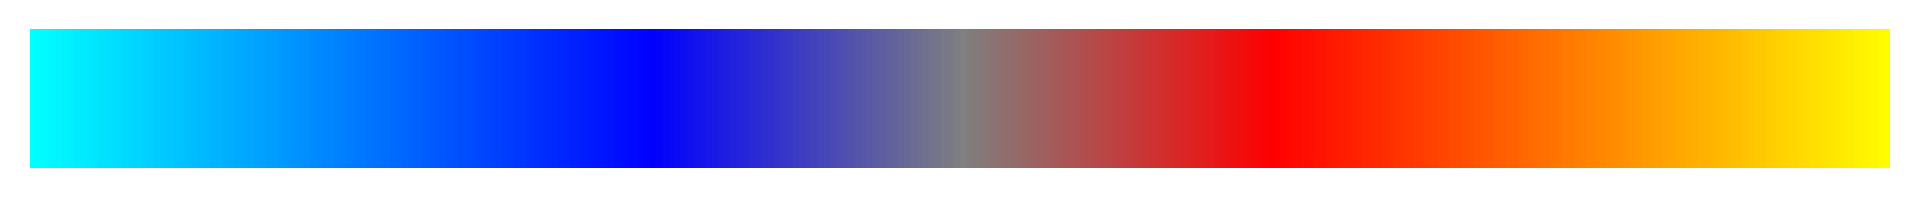

In [4]:
cmap_name = '../libraries/colourmaps/render3.cmap'

with open(cmap_name, 'r') as f:
    
    lines = f.readlines()
    
cmap_list = [[float(y) for y in x.split('\n')[0].split(' ')] for x in lines]

mymap = mcolors.ListedColormap(cmap_list)

fig, ax = plt.subplots(figsize=(8, 0.6), dpi=300)
cb = ColorbarBase(ax, cmap=mymap, orientation='horizontal')
cb.set_ticks([])
cb.outline.set_visible(False)
ax.set_axis_off()
fig.patch.set_alpha(0)

save_path = output_root / f'colorbar.svg'

plt.savefig(save_path, format="svg", transparent=True, bbox_inches="tight", pad_inches=0)

In [5]:

################ Output

save_dir = Path('/media/DATA2/fUS/Chiara/PepeMariani2025/figures/figure3/trasparency/')
    

# Computes FC and SC

## FC

Population FC martix is computed following these steps:
- individual preprocessed timeseries are loaded
    - BOLD 4D timeseries are standardized voxel wise
- ROI timeseries are extracted parcel wise based on the reference parcellation
- Pearson's correlation coefficient is computed edge-wise (ROI-to-ROI)
- The FC matrix is Fisher transformed (`np.arctanh`) for statistics
- The average FC over the full cohort is computed in the Fisher domain and expressed back in Pearson's for convention (*i.e.* `FC_mat`)

For the `SFC` analysis
- The FC matrix is gaussianised (*i.e.* `FC_norm`) by applying the fisher transform and scaling to unity.

### Parameters

In [6]:
# fUSI

regimen = 'CPXISO'

root_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/preprocessed/')
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{regimen}.*aCompCor.*pwd.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files:\n')

for x in root_dir:
    
    print(x.name)

save_dir = output_root / f'FC'
save_dir.mkdir(exist_ok = True, parents = True)

We found 13 files:

sub-cp230328a_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230328b_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230329b_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230330a_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230331a_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230331b_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230412a_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGaCompCorFilteredSmoothedSTCscrubbed_pwd.nii.gz
sub-cp230412c_ses-CPXISO_acq-3dfus_probe-linear_pose-vol_proc-c

### Loading

Loads BOLD 4D timeseries and generates subject level FC matrix.

In [7]:
# loading timeseries and computing subjectwise correlation matrices

correlation_matrices = []

for i,file_name in enumerate(root_dir):

    print(f'File : {i+1:<3} / {len(root_dir):>3}')
    
    cor_mat = compute_correlation_matrix(
        file_name,
        roi_list
    )
    
    correlation_matrices.append(cor_mat)

File : 1   /  13


extracting signals...: 100%|████████████████| 108/108 [00:14<00:00,  7.65it/s]


File : 2   /  13


extracting signals...: 100%|████████████████| 108/108 [00:13<00:00,  8.17it/s]


File : 3   /  13


...

extracting signals...: 100%|████████████████| 108/108 [00:13<00:00,  8.23it/s]


File : 12  /  13


extracting signals...: 100%|████████████████| 108/108 [00:13<00:00,  8.25it/s]


File : 13  /  13


extracting signals...: 100%|████████████████| 108/108 [00:13<00:00,  8.23it/s]


In [8]:
# computes the average FC matrix in Fisher domain and transforms back in Pearson's
FC_mat = np.tanh(np.arctanh(np.array(correlation_matrices)).mean(0))

# saves the correlation matrices
np.save(
    save_dir / f'correlation_matrices.npy',
    correlation_matrices
)

/tmp/ipykernel_3185178/521986116.py:2: RuntimeWarning: divide by zero encountered in arctanh
  FC_mat = np.tanh(np.arctanh(np.array(correlation_matrices)).mean(0))


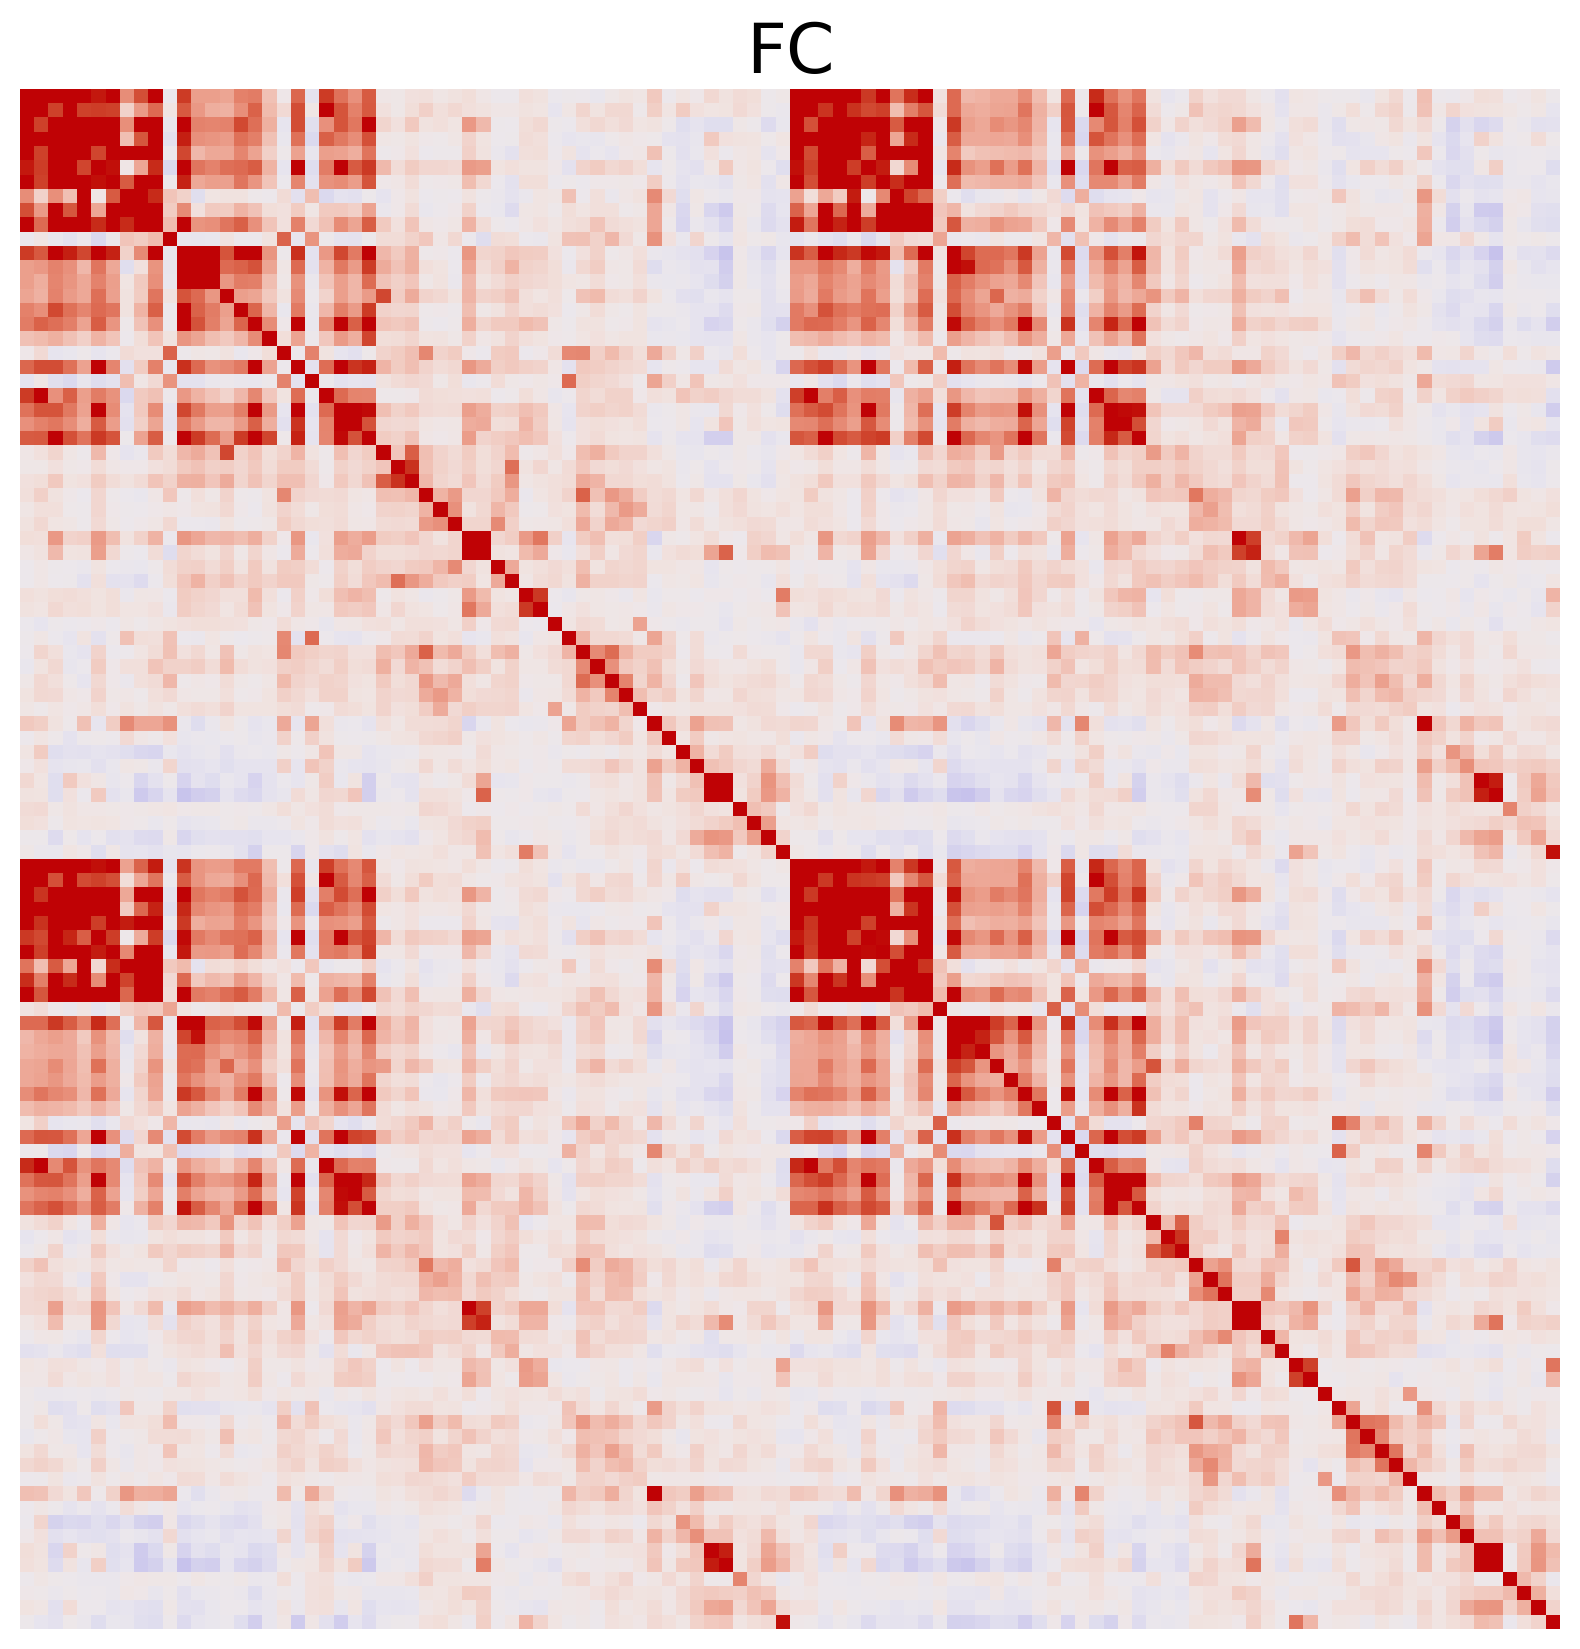

In [9]:
# Displays correlation in Pearson domain

plt.figure(figsize = (10,10), dpi = 200)

plt.imshow(FC_mat, cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.axis('off')

plt.title('FC', fontsize = 25)

save_name = save_dir / 'FC_matrix.png'
plt.savefig(save_name)
save_name = save_dir / 'FC_matrix.svg'
plt.savefig(save_name)

In [10]:
# Fisher + centering

FC_norm = np.arctanh(FC_mat)/(np.arctanh(FC_mat)[np.tril(np.ones([len(FC_mat)]*2), k = -1)>0]).std()
FC_norm[np.isnan(FC_norm) | np.isinf(FC_norm)] = 0

/tmp/ipykernel_3185178/2833930487.py:3: RuntimeWarning: divide by zero encountered in arctanh
  FC_norm = np.arctanh(FC_mat)/(np.arctanh(FC_mat)[np.tril(np.ones([len(FC_mat)]*2), k = -1)>0]).std()


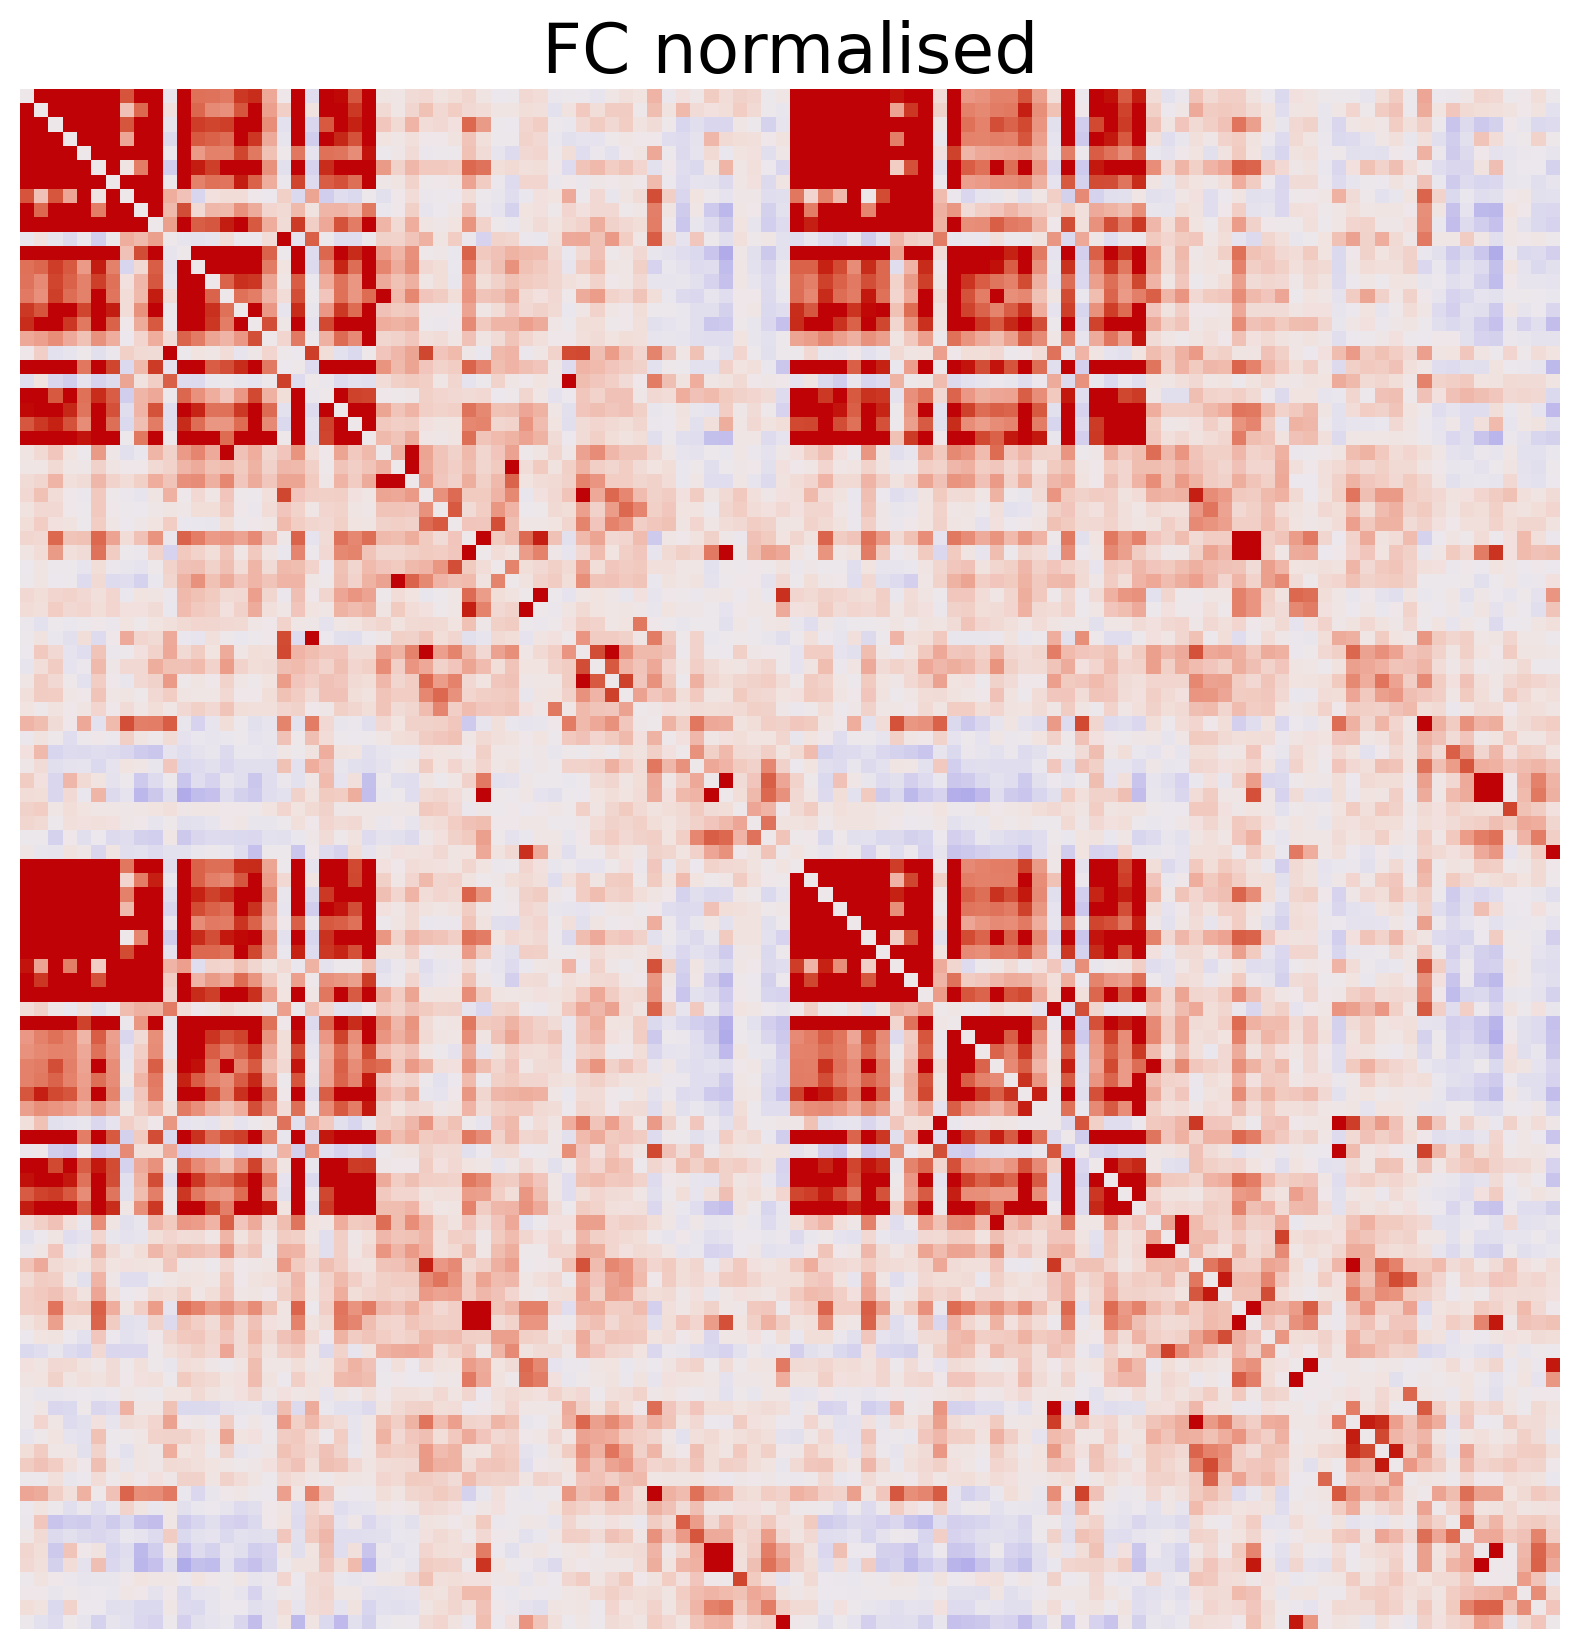

In [11]:
# Displays normalised FC

plt.figure(figsize = (10,10), dpi = 200)

# plt.imshow(np.arctanh(cor_mat_avg), cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.imshow(FC_norm, cmap = cc.cm['CET_D1'], vmin = -2, vmax = 2)
plt.axis('off')

plt.title('FC normalised', fontsize = 25)

save_name = save_dir / 'FC_matrix_normalised.png'
plt.savefig(save_name)
save_name = save_dir / 'FC_matrix_normalised.svg'
plt.savefig(save_name)

## SC

### Constructing the SC 

The Structural Connectome is constructed from the Allen Brain Atlas API as described in [Oh et al. 2014](https://www.nature.com/articles/nature13186). The packae assumes symmetry of the structural connectome and generates two connectivity matrix Ipsilateral (`right`: connectivity between regions in the same hemisphere) and contralateral (`left`: connectivity betweeen hemispheres). The complete matrix is generated by a block design:

| Right    | Left      |
|----------|----------|
| Left    | Right      |

The resulting matrix encodes for a directed network. Given the symmetrical nature of the FC matrix due to the commutativity of the correlation operator the resulting SC matrix is symmetrised representing the average input and output connection from each nodes to the rest of the network. 

Similarly as for the FC matrix for the `SFC` analysis:

- The SC matrix is gaussianised by log transform as well as centred (as SC values are positive only) and scaled to unity.

### Parameters

In [12]:
# Ipsilateral connectivity
right_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/connectomic/SC/ncd_right_hem.txt')
# Contralateral connectivity
left_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/Params/connectomic/SC/ncd_left_hem.txt')

save_dir = output_root / f'SC'
save_dir.mkdir(exist_ok = True, parents = True)

In [13]:
# Generating block designed SC matrix

sc_list = []

with open(right_name, 'r') as f:
    
    for row in f.readlines():
        
        sc_list.append([float(x) for x in row.split('\n')[0].split('\t')])
        
sc_data_right = np.array(sc_list)

sc_list = []

with open(left_name, 'r') as f:
    
    for row in f.readlines():
        
        sc_list.append([float(x) for x in row.split('\n')[0].split('\t')])
        
sc_data_left = np.array(sc_list)

# sc matrix

sc = np.block(
    [[sc_data_right, sc_data_left], [sc_data_left, sc_data_right]]
)

# symmetrise

sc_sym = np.zeros(sc.shape)
for i in range(sc.shape[0]):
    for j in range(sc.shape[1]):
        sc_sym[i,j] = sc[i,j] + sc[j,i]

sc_norm = np.log10(sc_sym)

SC_mat = sc_norm-sc_norm[np.tril(np.ones([len(sc_norm)]*2), k = -1)>0].mean()
SC_mat = SC_mat/SC_mat[np.tril(np.ones([len(sc_norm)]*2), k = -1)>0].std()

In [14]:
# Saving the matrix

np.save(
    save_dir / f'structural_matrices.npy',
    SC_mat
)

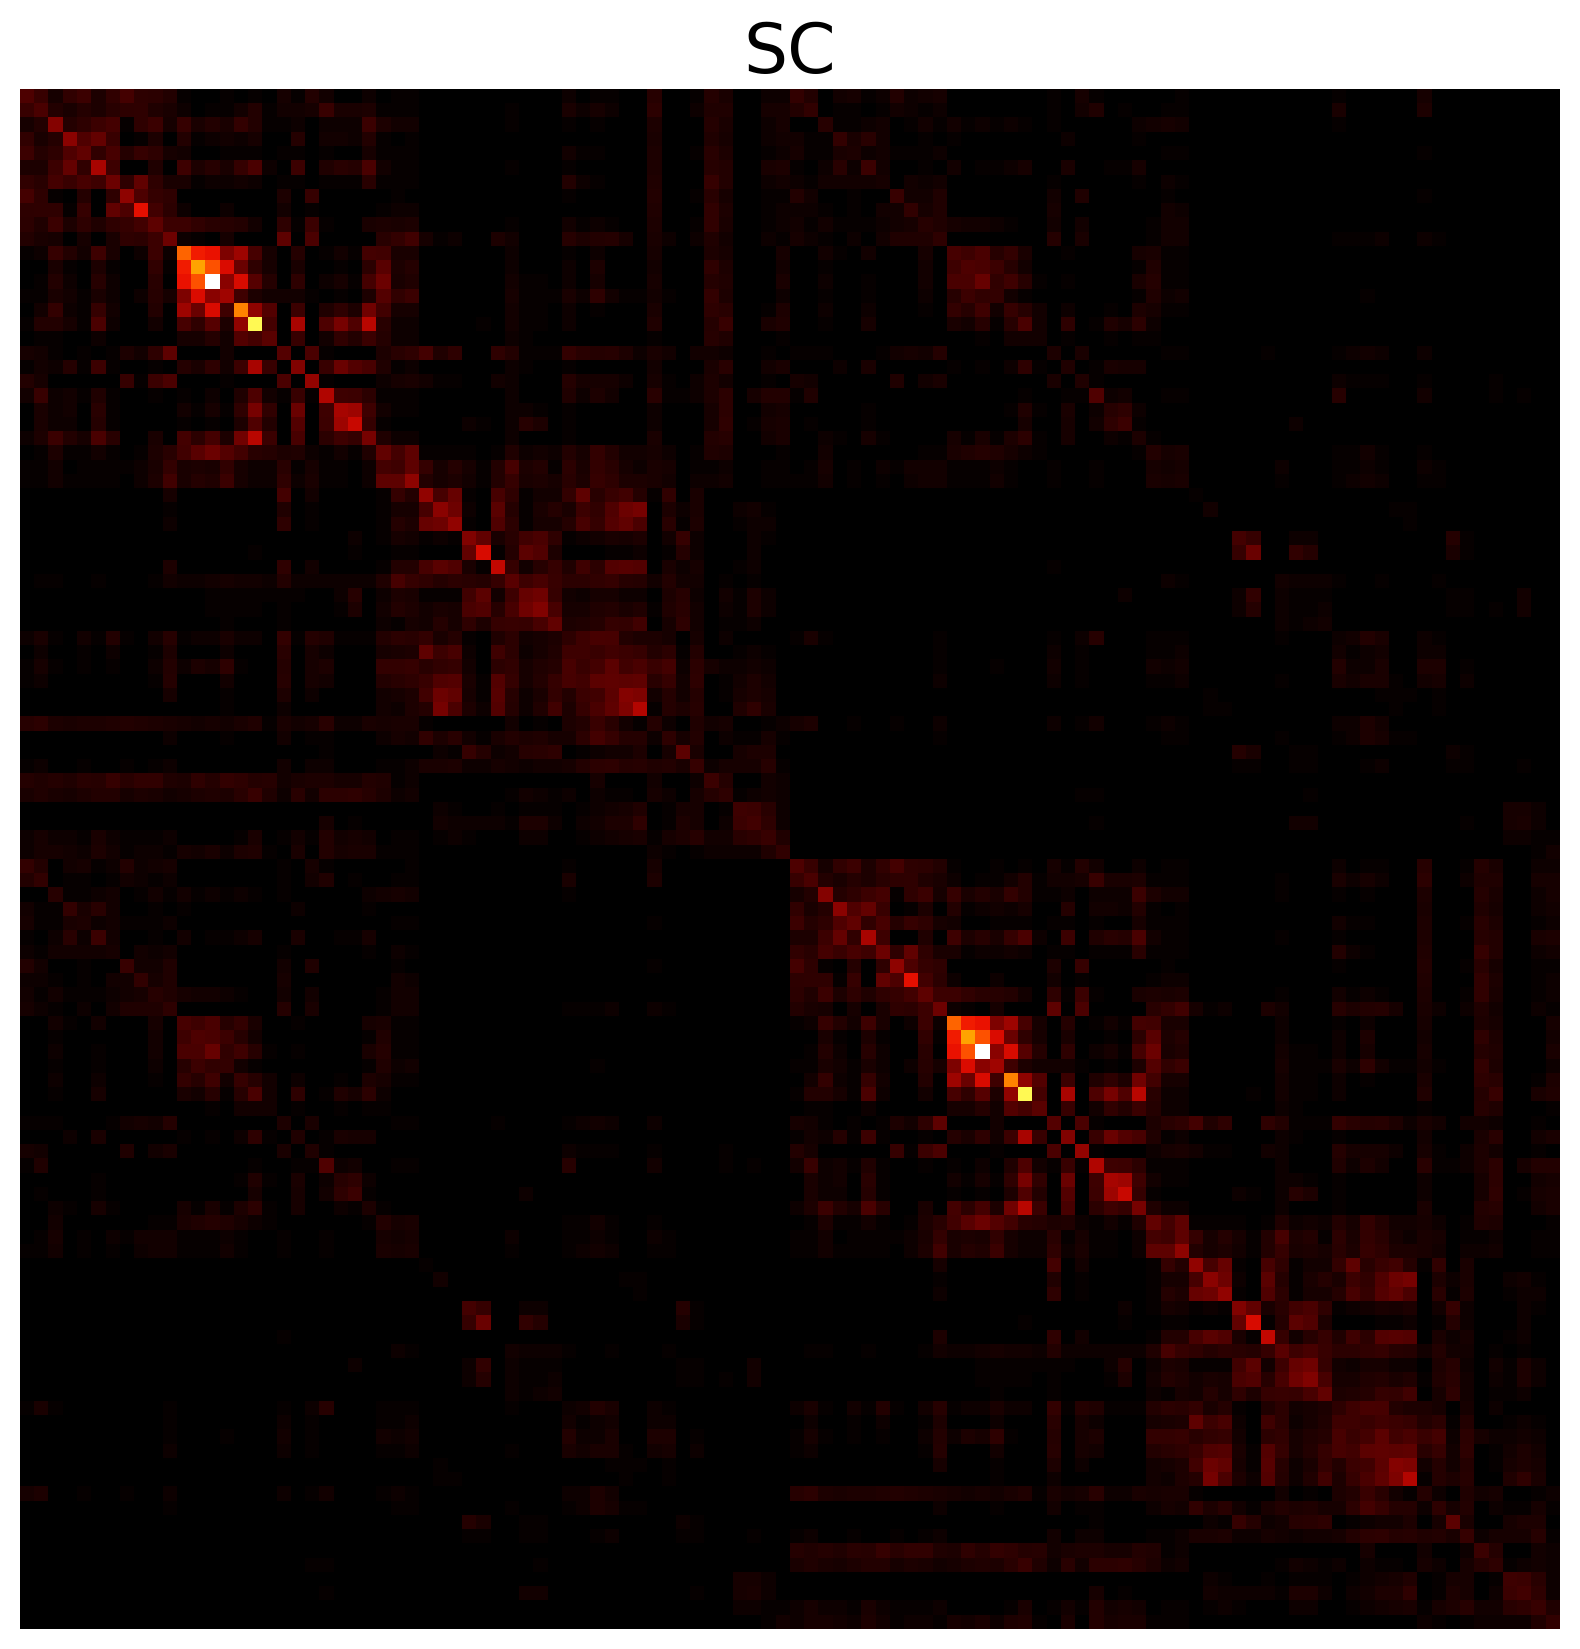

In [15]:
# Displays the raw matrix

plt.figure(figsize = (10,10), dpi = 200)

cm = abs(sc_sym).max()

# plt.imshow(np.arctanh(cor_mat_avg), cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.imshow(sc_sym, cmap = cc.cm['fire'], vmin = 0, vmax = cm)
plt.axis('off')

plt.title('SC', fontsize = 25)

save_name = save_dir / 'SC_matrix_raw.png'
plt.savefig(save_name)
save_name = save_dir / 'SC_matrix_raw.svg'
plt.savefig(save_name)

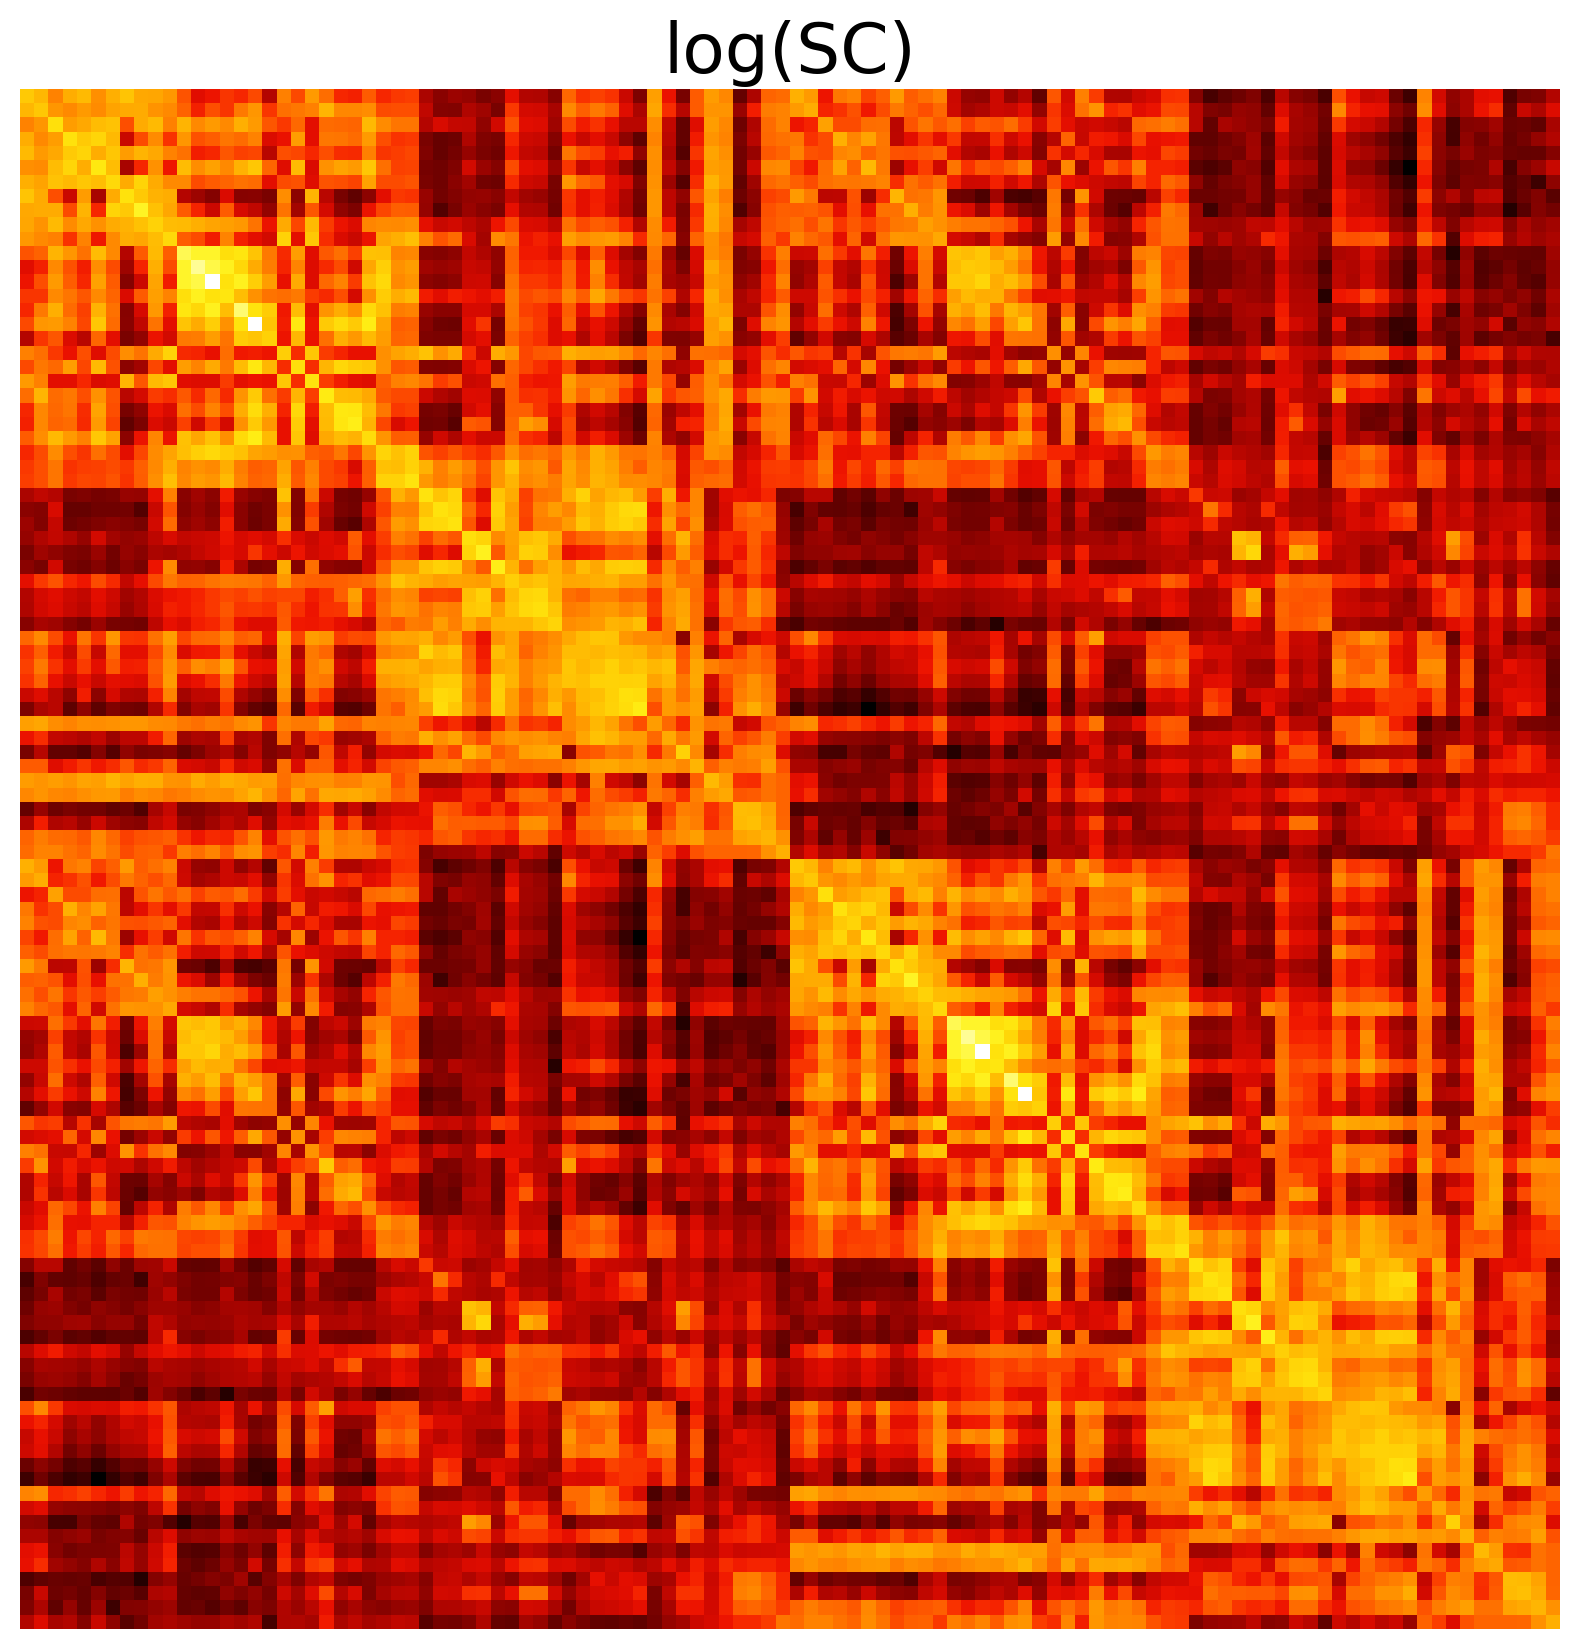

In [16]:
# Displays the log transformed matrix

plt.figure(figsize = (10,10), dpi = 200)

cm = abs(sc_norm).max()

# plt.imshow(np.arctanh(cor_mat_avg), cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.imshow(sc_norm, cmap = cc.cm['fire'])
plt.axis('off')

plt.title('log(SC)', fontsize = 25)

save_name = save_dir / 'SC_matrix_log.png'
plt.savefig(save_name)
save_name = save_dir / 'SC_matrix_log.svg'
plt.savefig(save_name)

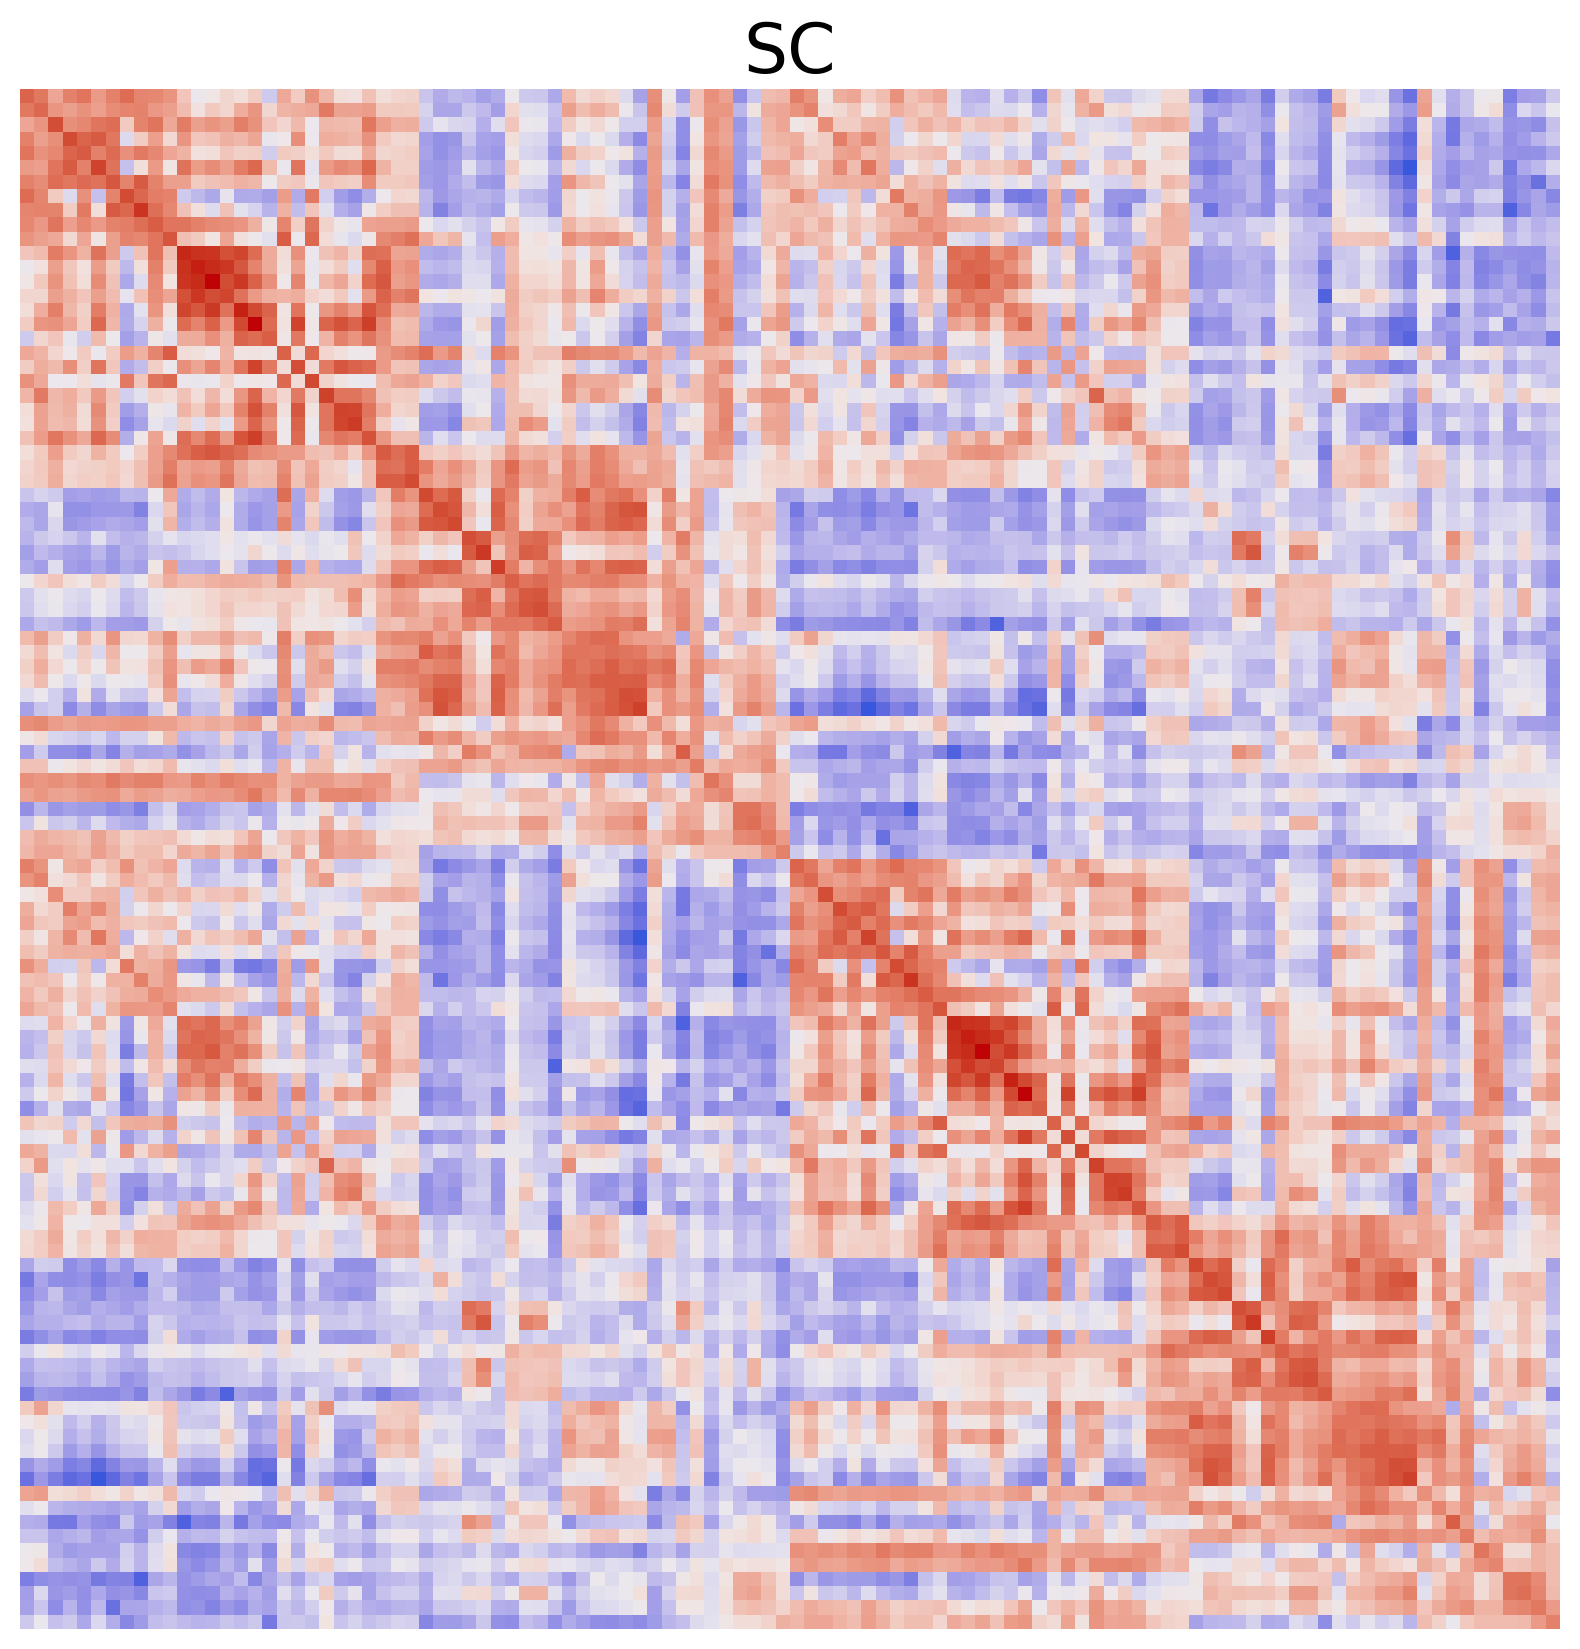

In [17]:
# Displays the standardised matrix

plt.figure(figsize = (10,10), dpi = 200)

cm = abs(SC_mat).max()

# plt.imshow(np.arctanh(cor_mat_avg), cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.imshow(SC_mat, cmap = cc.cm['CET_D1'], vmin = -cm, vmax = cm)
plt.axis('off')

plt.title('SC', fontsize = 25)

save_name = save_dir / 'SC_matrix.png'
plt.savefig(save_name)
save_name = save_dir / 'SC_matrix.svg'
plt.savefig(save_name)

# Network level SFC

In this section FC and SC are compared at the network level, *i.e.* edge wise correlation.

## Parameters

In [18]:
save_dir = output_root / f'SFC/network'
save_dir.mkdir(exist_ok = True, parents = True)

## Normalisation

Resulting symmetrical matrices are transformed into vector for the network level analysis.

In [19]:
SC_norm = SC_mat.copy()

FC_norm_vect = from_mat_2_vect(FC_norm)
SC_norm_vect = from_mat_2_vect(SC_norm)

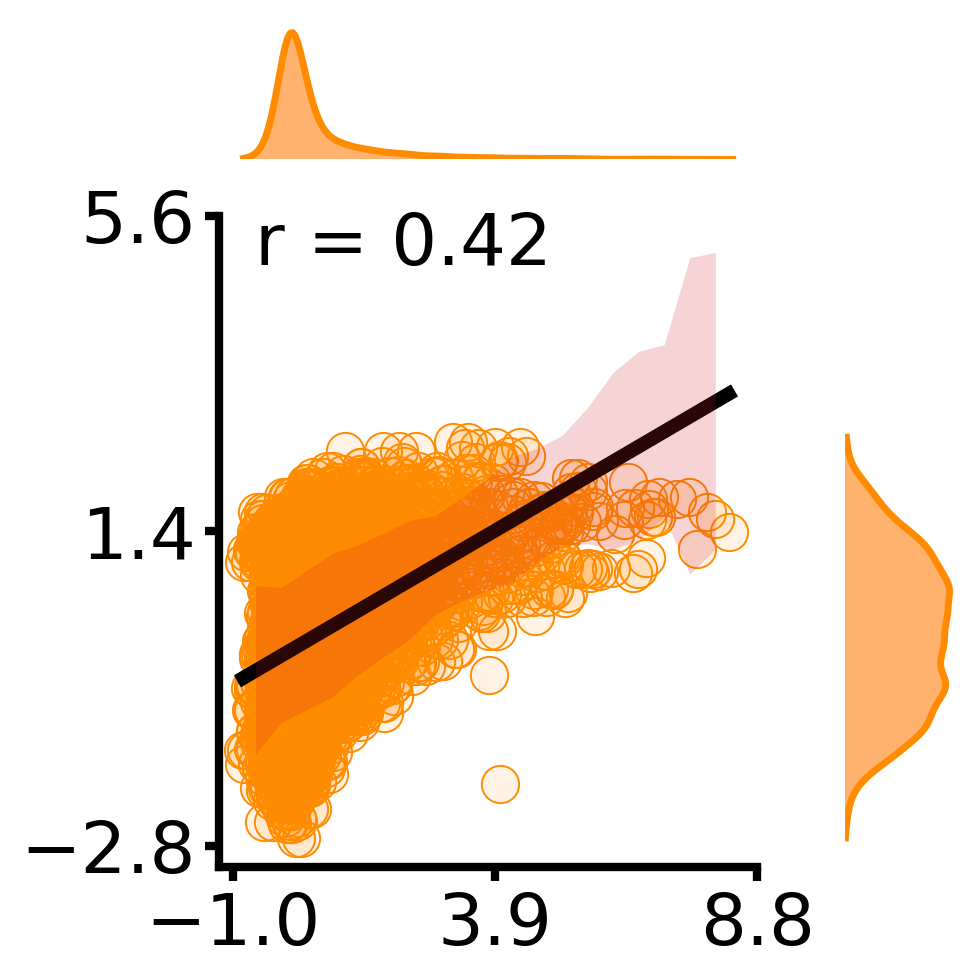

In [20]:
custom_join_plot(FC_norm_vect, SC_norm_vect)

save_name = save_dir / 'SFC_network_correlation.png'
plt.savefig(save_name)
save_name = save_dir / 'SFC_network_correlation.svg'
plt.savefig(save_name)


# Parcel level SFC

In this section SFC relationship is investigated at the parcel level. Two analyses are performed:

- Correlation is computed linewise between FC and SC resulting in a map of correlation between the two quantities
- The properties of SFC correspondance is investigated at the network level based on ABA ontology

## Parameters

In [21]:
# display parameters

[X,Y,Z] = template_hr_img.get_fdata().shape

vmin_allen = template_hr_img.get_fdata()[:,int(Y/2)-50:int(Y/2)+50,int(Z/2)-50:int(Z/2)+50].min()
vmax_allen = template_hr_img.get_fdata()[:,int(Y/2)-50:int(Y/2)+50,int(Z/2)-50:int(Z/2)+50].max()

# resample parcellation in high resolution for display

parcel_img = resample_img(
    parcellation_img,
    target_affine=template_hr_img.affine,
    target_shape=template_hr_img.shape,
    interpolation='nearest',
    copy_header=True,
    force_resample=True
)

smoothed_parcels = []

for slice_img in parcel_img.get_fdata():
    
    smoothed_parcels.append(
        smooth_high_res_cluster(
            slice_img, 
            sigma = 4.,
            th = 0.25
        )
    )

parcel_scan = nib.Nifti1Image(
    np.array(smoothed_parcels),
    affine = parcel_img.affine,
    header = parcel_img.header
)

# Output directory

save_dir = output_root / f'SFC/parcels'
save_dir.mkdir(exist_ok = True, parents = True)

## Maps

In [22]:
# standardisation linewise

FC_norm = FC_norm-FC_norm.mean(1)
FC_norm = FC_norm/FC_norm.std(1)

SC_norm = SC_norm-SC_norm.mean(1)
SC_norm = SC_norm/SC_norm.std(1)

# computes the correlation

SFC_vect = []

for i,(x,y) in enumerate(zip(FC_norm, SC_norm)):
    
    x = x[np.arange(len(x)) != i]
    y = y[np.arange(len(y)) != i]
    
    SFC_vect.append(np.corrcoef(x,y)[0,1])
    
SFC_vect = np.arctanh(np.array(SFC_vect))

SFC_img = from_vector_2_map(SFC_vect, parcel_scan)

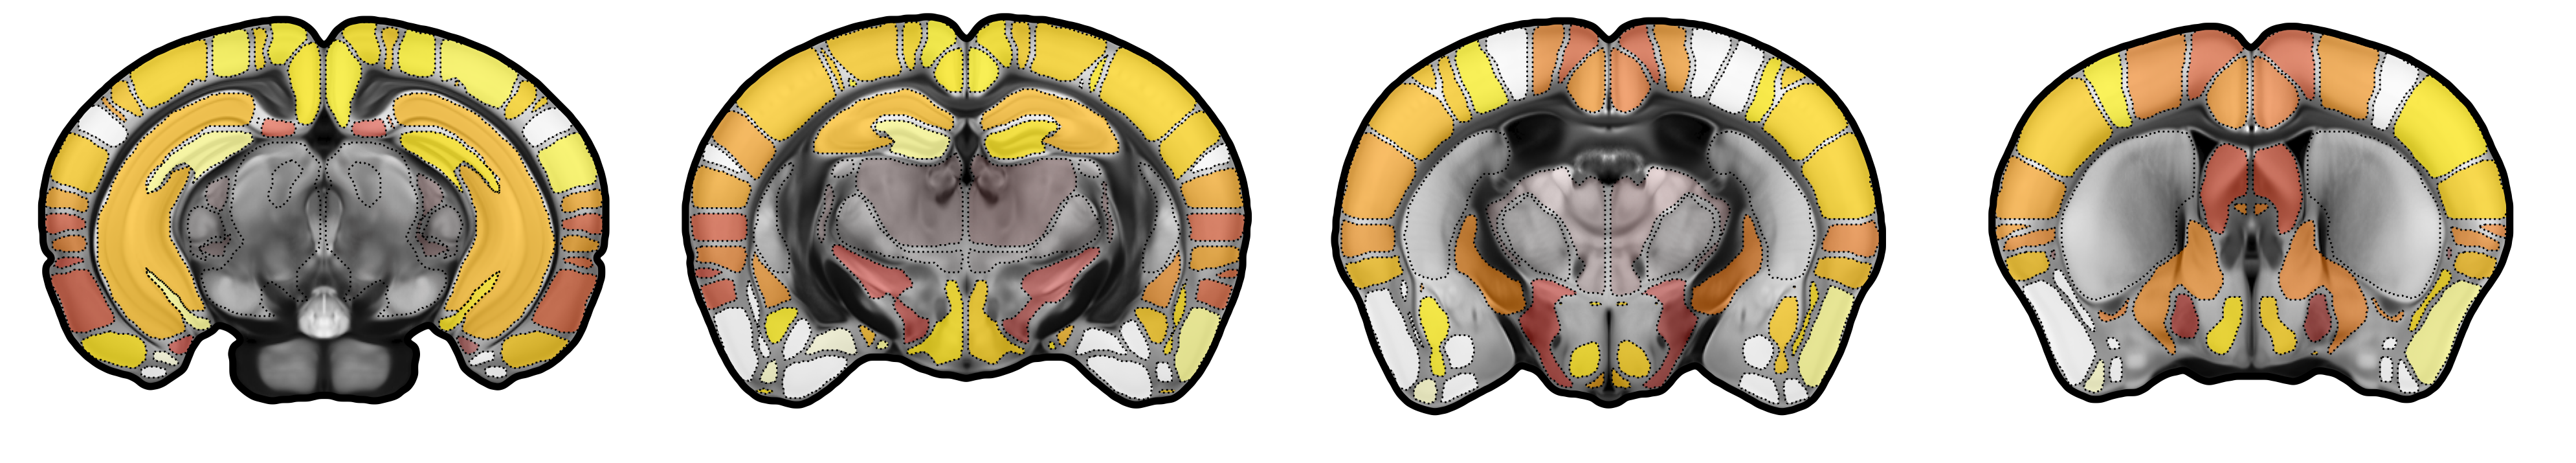

In [26]:
# Overlay High Res

cm = 0.9

fig, ax = plt.subplots(1,nb_col,figsize = (nb_col*5, 4), facecolor = 'white', dpi = 200)

img1 = template_hr_img.get_fdata()
img2 = SFC_img.get_fdata()

[X,Y,Z] = img2.shape


for sliceID in range(nb_col):

    a = img1[sliceID,:,:]
    mask = binary_fill_holes(a > 10)
    ax[-1-sliceID].imshow(a, cmap = 'Greys_r', vmin = vmin_allen, vmax = vmax_allen, alpha = mask.astype(float))
    
    a = img2[sliceID,:,:]
    alpha = (abs(a)/cm).astype(float)
    # alpha = (parcel_scan.get_fdata()[sliceID,:,:]>0)
    alpha[alpha>1] = 1
    ax[-1-sliceID].imshow(a, cmap = cc.cm['fire'], vmin = 0, vmax = cm, alpha = 0.8*mask*(alpha).astype(float))
    
    ax[-1-sliceID].contour(gaussian_filter(1.*mask,2), levels = [0.5], colors = ['k'], linewidths = [4])
    
    ax[-1-sliceID].axis('off')

    # contour of ROIs

    img_2_display = parcel_scan.get_fdata()[sliceID,:,:]
    
    for level in np.unique(img_2_display)[1:]:
        ax[-1-sliceID].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [1], linestyles = ':')
    
plt.tight_layout()

save_name = save_dir / 'SFC_parcel-wise_correlation.png'
plt.savefig(save_name)
save_name = save_dir / 'SFC_parcel-wise_correlation.svg'
plt.savefig(save_name)


## Lollipop

This section further investigate the network organisation of SFC correspondance at the parcel level.

In [27]:
# redesign of ABA ontology CNU -> STR

roi_df['AllenNetwork'] = roi_df['AllenNetwork'].replace('CNU', 'STR')

# Allen

# define colours

color_dict = {
    'STR':[202,195,0],
    'CTXsp':[218,149,255],
    'HPF':[124,89,0],
    'HY':[172,147,235],
    'Iso':[70,72,0],
    'MB':[167,107,154],
    'OLF':[163,80,168],
    'TH':[47,61,168],
}

color_list = []

for x in roi_df['AllenNetwork']:

     color_list.append(color_dict[x])

### Parcel level

Orders parcels based on SFC correspondance to make emerge gradient organisation of FC embedding on SC. For this purpose the average value across left and right hemisphere is taken.

In [28]:
# Generate parameter for matchig parcels with ABA ontology

new_order = list(np.unique(roi_df['AllenNetwork']))

# ordering of the networks

nb_clusters = 2*len(new_order)

isort = np.array([])[:,None]
v = np.array([])

cluster_data = np.zeros(template_img.shape)

k = 0
boundary = []

# for j,hemi in enumerate(['left', 'right']):

for i,key in enumerate(new_order):

    # ind_list = np.argwhere(np.array((roi_df['LudoNetwork'] == key)&(roi_df['hemisphere'] == hemi)))
    ind_list = np.argwhere(np.array((roi_df['AllenNetwork'] == key)))
    
    isort = np.concatenate((isort, ind_list)).astype(int)
    v = np.concatenate((v,(1+i+j*len(new_order))*np.ones(len(ind_list))))
    
    k = k+len(ind_list)
    boundary.append(k)
    
    for idx in ind_list:
    
        cluster_data[parcellation_img.get_fdata() == idx+1] = (1+i)
    
cluster_img = nib.Nifti1Image(
    cluster_data,
    affine = parcellation_img.affine
)
        
isort = isort.squeeze()
boundary = boundary[:-1]

In [29]:
# Display of the netowrks for high resolution visual checks

# upsample the parcellation

parcellation_hr_img = resample_img(
    parcellation_img,
    target_affine=template_hr_img.affine,
    target_shape=template_hr_img.shape,
    interpolation='nearest',
    copy_header=True,
    force_resample=True
)

# exracts triplet per smoothed upsampled ROI

smoothed_allen = np.zeros((3,) + parcellation_hr_img.shape)

for i in range(parcellation_img.shape[0]):
    
    current_slice = smooth_high_res_cluster(
            parcellation_hr_img.get_fdata()[i,:,:], 
            sigma = 4.,
            th = 0.25
        )

    for idx, network in zip(roi_df['id'], roi_df['AllenNetwork']):

        inds = np.argwhere((current_slice == idx))
        triplet = color_dict[network]
        
        for k,l in zip(inds[:,0], inds[:,1]):

            smoothed_allen[:,i,k,l] = np.array(triplet)/255

rgb_scan = np.array(smoothed_allen)

# Display the image

fig, ax = plt.subplots(1,nbCol,figsize = (nbCol*5, 4), facecolor = 'white', dpi = 200)

img1 = template_hr_img.get_fdata()
img2 = rgb_scan

[X,Y,Z] = img1.shape

for sliceID in range(nbCol):

    a = img1[sliceID,:,:]
    mask = binary_fill_holes(a > 10)
    ax[-1-sliceID].imshow(a, cmap = 'Greys_r', vmin = vmin_allen, vmax = vmax_allen, alpha = mask.astype(float))
    
    a = img2[:,sliceID,:,:]
    # alpha = (abs(a)/cm).astype(float)
    alpha = (parcel_scan.get_fdata()[sliceID,:,:]>0)
    alpha[alpha>1] = 1
    ax[-1-sliceID].imshow(a.transpose(1,2,0), alpha = 0.7*mask*(alpha).astype(float))
    
    ax[-1-sliceID].contour(gaussian_filter(1.*mask,2), levels = [0.5], colors = ['k'], linewidths = [4])
    
    ax[-1-sliceID].axis('off')

    # contour of ROIs

    img_2_display = parcel_scan.get_fdata()[sliceID,:,:]
    
    for level in np.unique(img_2_display)[1:]:
        ax[-1-sliceID].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [1], linestyles = ':')
    
plt.tight_layout()

save_name = save_dir / 'SFC_Lollipop_parcel-wise_network_map.png'
save_name.parent.mkdir(exist_ok = True, parents = True)
plt.savefig(save_name)
save_name = save_dir / 'SFC_Lollipop_parcel-wise_network_map.svg'
plt.savefig(save_name)

NameError: name 'nbCol' is not defined

In [ ]:
## Lollipop plot mean across left and right

# Extract ROI base names 
roi_base = [name[3:] if name.startswith(('LH_', 'RH_')) else name for name in roi_df['acro']]

# Group by ROI base name and compute mean of left and right
roi_df['base'] = roi_base
SFC_mean = roi_df.groupby('base').apply(lambda df: SFC_vect[df.index].mean())

# Sort by mean values
indices = np.argsort(SFC_mean)
x_positions = np.arange(len(indices))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(22, 9), facecolor='w', dpi=200)
ax.set(facecolor='w')

cmap = cc.cm['fire']
ref_correlation = np.median(SFC_mean)

ax.axhline(0, c='k', lw=5, ls='--', zorder=0)

# Scatter plot with colormap
ax.scatter(x_positions, SFC_mean.iloc[indices.values],
           s=800,
           c=[cmap(SFC_mean.iloc[idx] / 0.9) for idx in indices.values],
           edgecolors='k',
           linewidth=0.8,
           zorder=3,
           alpha=0.8)

# X-ticks
ax.set_xticks(x_positions)
ax.set_xticklabels(SFC_mean.index[indices],
                   fontsize=16, fontweight='bold', color='k', rotation=90)

# Colored rectangles behind labels
for x, idx in zip(x_positions, indices.values):
    rect_color = cmap(SFC_mean.iloc[idx] / 0.9)
    rect = patches.Rectangle((x-0.45, -0.41),
                             1, 0.20,
                             facecolor=rect_color,
                             edgecolor='none',
                             alpha=0.5,
                             transform=ax.transData,
                             zorder=1,
                             clip_on=False
                            )
    ax.add_patch(rect)

# Axis formatting
ax.set_xlim(-1, len(indices))
ax.set_ylim(min(SFC_mean) - 0.1, max(SFC_mean) + 0.1)
ax.set_ylabel("r", fontsize=60, color='k', labelpad=10)
ax.tick_params(axis='y', colors='k', labelsize=40, width=5, length=11)
ax.tick_params(axis='x', colors='k', labelsize=18, width=5, length=11)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_linewidth(6)  # spessore asse x
ax.spines['left'].set_linewidth(6)    # spessore asse y


# Save outputs
save_name = save_dir / 'SFC_Lollipop-bilateral_noTrasparency_0.9.png'
save_name.parent.mkdir(exist_ok=True, parents=True)
plt.savefig(save_name, bbox_inches='tight', transparent= True)

save_name = save_dir / 'SFC_Lollipop-bilateralnoTrasparency_0.9.svg'
plt.savefig(save_name, bbox_inches='tight', transparent= True)

plt.show()


### Network level

The same analysis is performed at the network level.

In [ ]:
# defines the network level vector of SFC

network_SFC = []
network_SFC_var = []
network_list = []

for network in color_dict:

    network_SFC.append(SFC_vect[roi_df['AllenNetwork'] == network].mean())
    network_SFC_var.append(SFC_vect[roi_df['AllenNetwork'] == network].std())
    network_list.append(network)

network_SFC = np.array(network_SFC)
network_SFC_var = np.array(network_SFC_var)

nb_networks = len(network_SFC)

In [ ]:
# Generate parameter for matchig parcels with ABA ontology

new_order = list(np.unique(roi_df['AllenNetwork']))

nb_clusters = 2*len(new_order)

isort = np.array([])[:,None]
v = np.array([])

cluster_data = np.zeros(template_img.shape)

k = 0
boundary = []

# for j,hemi in enumerate(['left', 'right']):

for i,key in enumerate(new_order):

    # ind_list = np.argwhere(np.array((roi_df['LudoNetwork'] == key)&(roi_df['hemisphere'] == hemi)))
    ind_list = np.argwhere(np.array((roi_df['AllenNetwork'] == key)))
    
    isort = np.concatenate((isort, ind_list)).astype(int)
    v = np.concatenate((v,(1+i+j*len(new_order))*np.ones(len(ind_list))))
    
    k = k+len(ind_list)
    boundary.append(k)
    
    for idx in ind_list:
    
        cluster_data[parcellation_img.get_fdata() == idx+1] = SFC_vect[ind_list].mean()
    
cluster_img = nib.Nifti1Image(
    cluster_data,
    affine = parcellation_img.affine
)
        
isort = isort.squeeze()
boundary = boundary[:-1]

In [ ]:
# Filters the cluster display to join parcels in the same network

cluster_cleaned_data = np.zeros(cluster_img.shape)
for i in range(4):
    cluster_cleaned_data[i,:,:] = fill_holes_sw(cluster_img.get_fdata()[i,:,:])

cluster_cleaned_img = nib.Nifti1Image(
    cluster_cleaned_data,
    affine = cluster_img.affine
)

cluster_hr_img = resample_img(
    cluster_cleaned_img,
    target_affine=template_hr_img.affine,
    target_shape=template_hr_img.shape,
    interpolation='nearest',
    copy_header=True,
    force_resample=True
)

In [ ]:
# local display parameters

nb_col = 2
cmap = cc.cm['fire']

vmax = 0.9
vmin = 0

# display the map

fig,ax = plt.subplots(2,nb_col, figsize = (7*nb_col, 5*2), dpi = 200)

for slice_id in range(nb_col*2):

    i = (4-slice_id-1)//nb_col
    j = (4-slice_id-1)%nb_col
    
    ######################## Template

    img_2_display = template_hr_img.get_fdata()[slice_id,:,:].copy()
    current_mask = 1.*(binary_fill_holes(img_2_display>10))
    img_2_display[current_mask == 0] = np.nan

    ax[i,j].imshow(img_2_display, cmap = 'Greys_r', vmin = template_vmin, vmax = template_vmax)

    ax[i,j].contour(gaussian_filter(1.*current_mask,2), levels = [0.5], colors = ['k'], linewidths = [4])

    # ######################## image

    img_2_display = smooth_high_res_cluster(
    
        cluster_hr_img.get_fdata()[slice_id,:,:].copy(),
        sigma = 4,
        th = 0.25
    )
    img_2_display[current_mask == 0] = 0

    ax[i,j].imshow(img_2_display, cmap = cmap, vmin = vmin, vmax = vmax, alpha = 0.7*(img_2_display>0), interpolation = 'nearest')
    for level in np.unique(img_2_display)[1:]:
        ax[i,j].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [2], linestyles = ':')

    ax[i,j].axis('off')

plt.tight_layout()

save_name = save_dir / 'SFC_Lollipop-networkMap_network-wise_fire.png'
save_name.parent.mkdir(exist_ok = True, parents = True)
plt.savefig(save_name)
save_name = save_dir / 'SFC_Lollipop-networkMap_network-wise_fire.svg'

plt.savefig(save_name)

In [ ]:
# netwrok-wise lollipop plot

# Settings
back_color = 'w'
front_color = 'k'
cmap = cc.cm['fire']

indices = np.argsort(network_SFC)
nb_networks = len(network_SFC)
x_positions = np.arange(nb_networks)

fig, ax = plt.subplots(1, 1, figsize=(11, 7), facecolor=back_color, dpi=300)
ax.set(facecolor=back_color)

# Scatter plot with variance
ax.scatter(x_positions, network_SFC[indices],
           s=2000,
           c=[cmap(val / 0.9) for val in network_SFC[indices]],
           edgecolors='k',
           linewidth=1.2,
           zorder=3,
           alpha=0.8)

# Variance bars (vertical now)
for i, idx in enumerate(indices):
    low = network_SFC[idx] - network_SFC_var[idx]
    high = network_SFC[idx] + network_SFC_var[idx]
    
    # Black outline
    ax.plot([i, i], [low, high], c='k', lw=7, zorder=1)
    
    # Colored variance bar overlay
    ax.plot([i, i], [low, high],
            c=cmap(network_SFC[idx] / 0.9),
            lw=20, alpha=0.6, zorder=2)

# X-ticks = networks
ax.set_xticks(x_positions)
ax.set_xticklabels([network_list[idx] for idx in indices],
                   fontsize=46, fontweight='bold', color=front_color, rotation=90)

# Colored rectangles behind labels
for x, idx in zip(x_positions, indices):
    rect_color = cmap(network_SFC[idx] / 0.9)
    rect = patches.Rectangle((x-0.45, -0.71),
                             1, 0.50,        # width, height
                             facecolor=rect_color,
                             edgecolor='none',
                             alpha=0.5,
                             transform=ax.transData,
                             zorder=1,
                             clip_on=False)
    ax.add_patch(rect)

# Axis limits
ax.set_xlim(-1, nb_networks)
ax.set_ylim(min(network_SFC - network_SFC_var) - 0.1,
            max(network_SFC + network_SFC_var) + 0.1)

# Labels and style
ax.set_ylabel("r", fontsize=60, color=front_color, labelpad=10)
ax.tick_params(axis='y', colors=front_color, labelsize=32, width=7, length=12)
ax.tick_params(axis='x', width=7, length=12)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set(color=front_color, linewidth=6)
ax.spines['left'].set(color=front_color, linewidth=6)

# Save outputs

save_name_png = save_dir / 'SFC_Lollipop-horizontalVariance_fire_biggeraxis.png'
save_name_png.parent.mkdir(exist_ok=True, parents=True)
fig.savefig(save_name_png, bbox_inches='tight', transparent=True)

save_name_svg = save_dir / 'SFC_Lollipop-horizontalVariance_fire_biggeraxis.svg'
fig.savefig(save_name_svg, bbox_inches='tight', transparent=True)

plt.show()





In [ ]:
# quantitative estimates

print("\nCorrelation per network (boxed):\n")
for idx in indices:
    print("-----------")
    print(f"{network_list[idx]}")
    print(f"r = {network_SFC[idx]:.4f}")
    print("-----------\n")


# SFC PCA

This section performs a multivariate analysis of SFC correspondance at the parcel level. It intends to find main axis of covariance highlighting joined embedding structure of FC and SC. The main steps of the analysis are as follow:

- FC and SC matrices are normalised linewise (already performed for the previous analysis *i.e.* `SC_mat` and `FC_mat`)
- The two matrices are concatenated along the lines
- A PCA is performed with SVD to inteprete individual PCs:
    - The singular value for the variance explained
    - The left vector qhose loading identify covarying regions in terms of SC AND FC
    - The right vector can be split in two, a first part indicating which FC pattern is associated to regions of similar loading, and an SC pattern for the associated structural connectome
- Correlation between SC and FC loading of the right vector is also performed to investigate how grounded in SFC equivalence is each component

## Parameters

In [30]:
SFC_mat = np.concatenate((FC_norm, SC_norm), 1)
SFC_mat[np.isnan(SFC_mat)] = 0

# Output directory

save_dir = output_root / f'SFC/PCA'
save_dir.mkdir(exist_ok = True, parents = True)

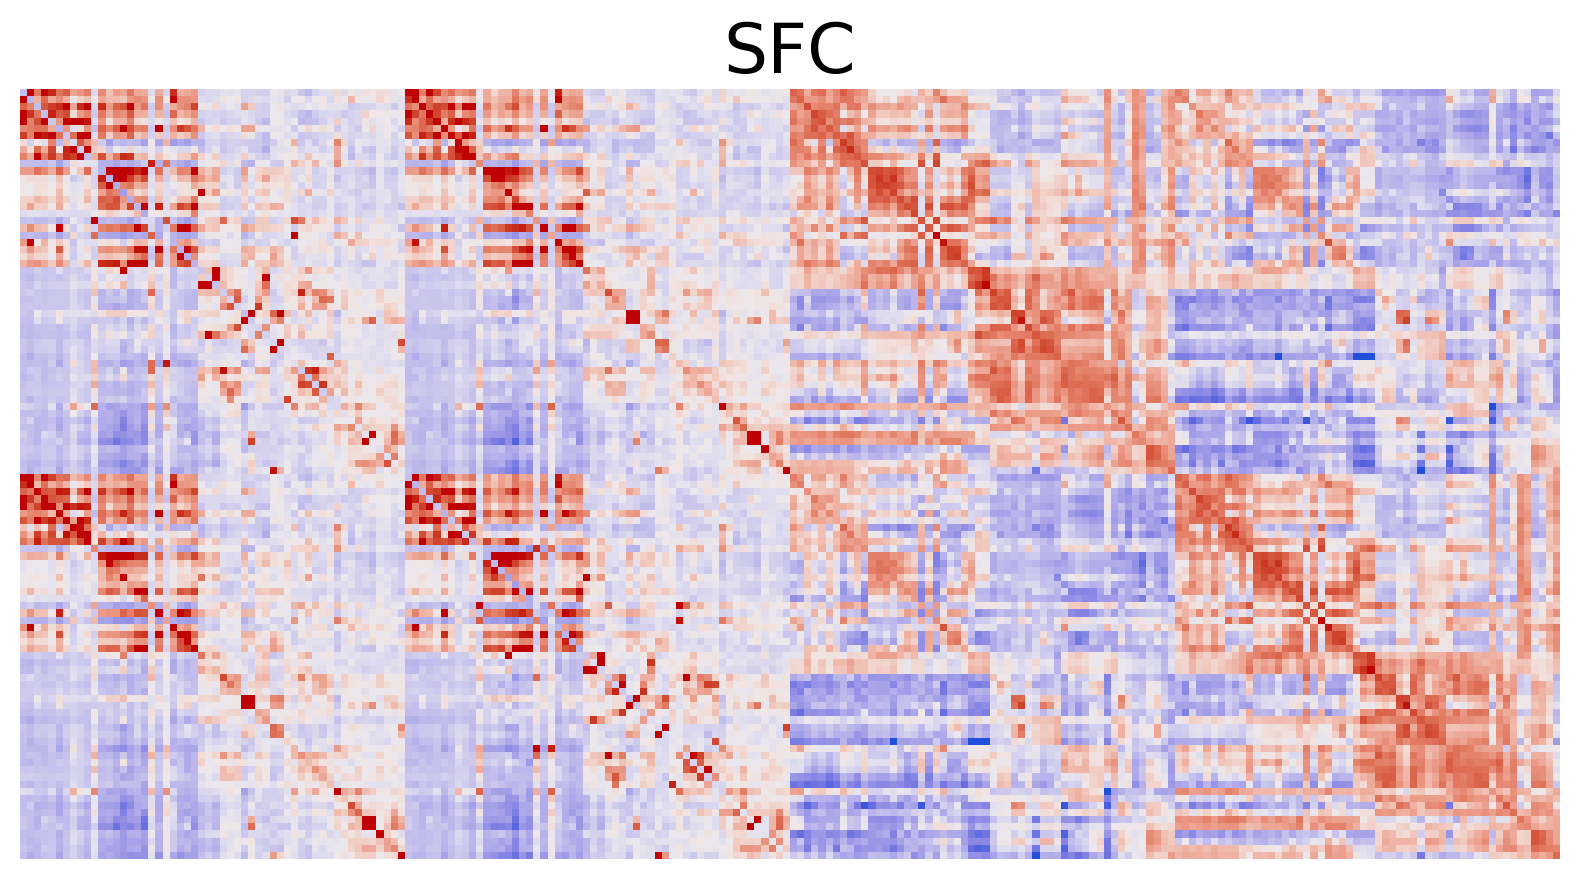

In [31]:
# displays SFC matrix

plt.figure(figsize = (10,5), dpi = 200)

# plt.imshow(np.arctanh(cor_mat_avg), cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.imshow(SFC_mat, cmap = cc.cm['CET_D1'], vmin = -3, vmax = 3)
plt.axis('off')

plt.title('SFC', fontsize = 25)

save_name = save_dir / 'SFC_matrix.png'
plt.savefig(save_name)
save_name = save_dir / 'SFC_matrix.svg'
plt.savefig(save_name)

## PCA

In [32]:
# Performs PCA with SVD

SFC_norm = SFC_mat.copy()
SFC_norm = SFC_norm - SFC_norm.mean(1)[:,None]
SFC_norm = SFC_norm / SFC_norm.std(1)[:,None]

SFC_norm[np.isnan(SFC_norm)] = 0

[u,s,v] = np.linalg.svd(SFC_norm)

## VE

In [33]:
# prints total variance explained by the selected components

VE = [x**2/(s**2).sum() for x in s]

print(VE[0] + VE[2] + VE[3] + VE[5])

0.5822305353301382


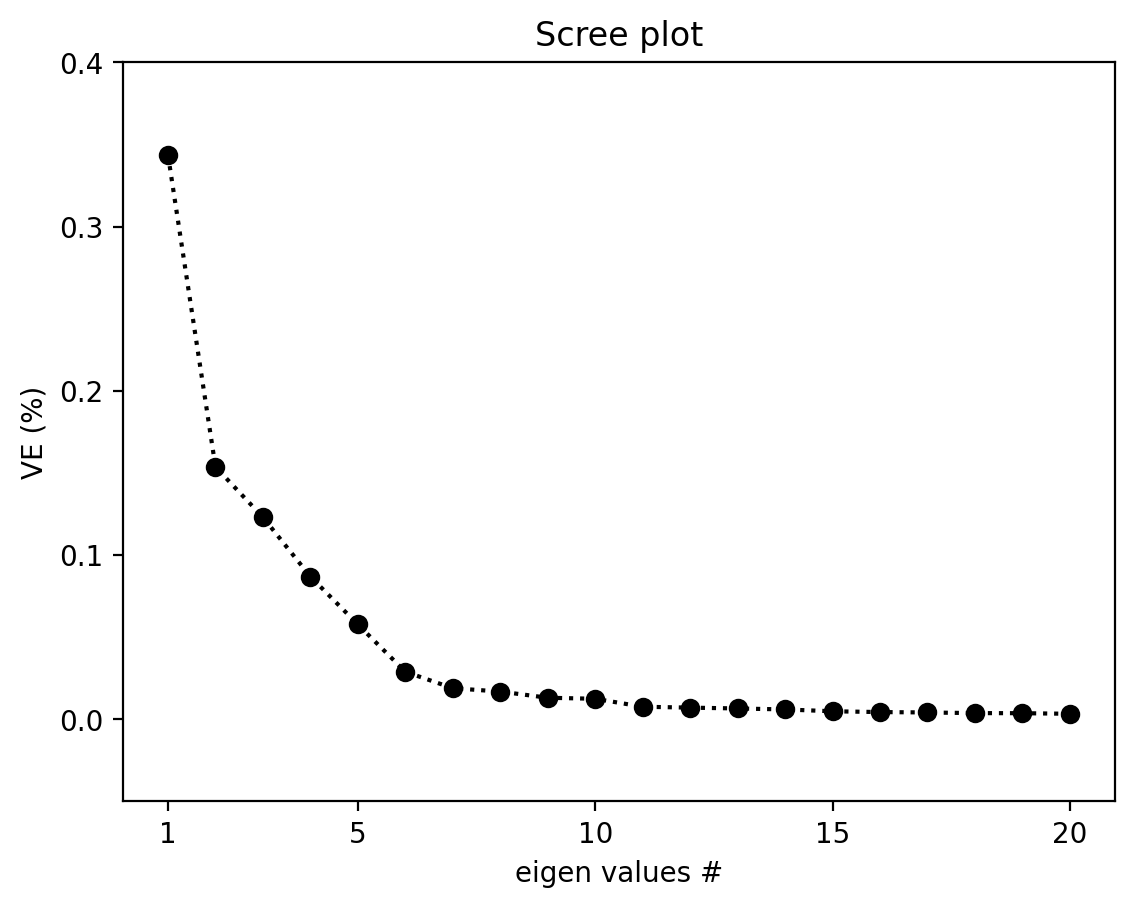

In [34]:
# displays the scree plots

plt.figure(dpi = 200)

nb_components = 20

VE = s**2/(s**2).sum()

plt.scatter(np.arange(nb_components)+1, VE[:nb_components], c = 'k')
plt.plot(np.arange(nb_components)+1, VE[:nb_components], ls = ':', c = 'k')

plt.ylim(-0.05,0.4)

plt.yticks([0,0.1,0.2,0.3,0.4])
plt.xticks([1,5,10,15,20])

plt.title('Scree plot')
plt.xlabel('eigen values #')
plt.ylabel('VE (%)')

# set the ticks

save_name = save_dir / 'scree_plot.png'
plt.savefig(save_name)
save_name = save_dir / 'scree_plot.svg'
plt.savefig(save_name)


In [35]:
# prints quantifications

n_show = 6

# individual variance explained
ve_first = VE[:n_show]

# cumulative variance explained
ve_cum = np.cumsum(VE)

print("\n=== VARIANCE EXPLAINED ===\n")

for i in range(n_show):
    print(f"PC{i+1}: VE = {ve_first[i]*100:.2f}% | cumulative = {ve_cum[i]*100:.2f}%")

print("\nTOTAL cumulative VE (first 6 PCs): "
      f"{ve_cum[n_show-1]*100:.2f}%")


=== VARIANCE EXPLAINED ===

PC1: VE = 34.34% | cumulative = 34.34%
PC2: VE = 15.36% | cumulative = 49.71%
PC3: VE = 12.30% | cumulative = 62.01%
PC4: VE = 8.69% | cumulative = 70.69%
PC5: VE = 5.77% | cumulative = 76.47%
PC6: VE = 2.89% | cumulative = 79.36%

TOTAL cumulative VE (first 6 PCs): 79.36%


In [36]:
# prints quantifications for selected components

selected_idx = [0, 2, 3, 5]  # PC1, PC3, PC4, PC6

df_selected = pd.DataFrame({
    "Component": [i+1 for i in selected_idx],
    "VE (%)": VE[selected_idx]*100,
    "Cumulative VE (%)": np.cumsum(VE)[selected_idx]*100
})

print("\n=== SELECTED COMPONENTS (PC1,3,4,6) ===\n")
print(df_selected.round(2))


=== SELECTED COMPONENTS (PC1,3,4,6) ===

   Component  VE (%)  Cumulative VE (%)
0          1   34.34              34.34
1          3   12.30              62.01
2          4    8.69              70.69
3          6    2.89              79.36


## Loadings

This section display results regarding the loadings.

### SC/FC loading correlation 

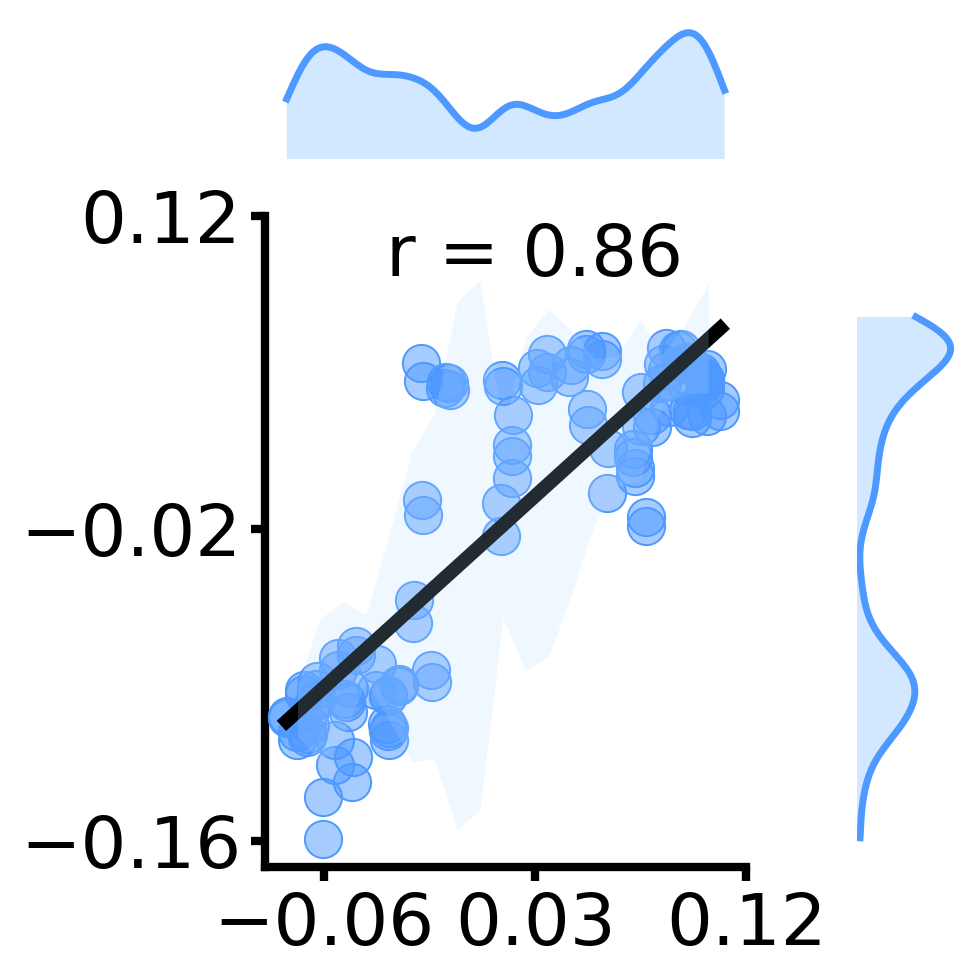

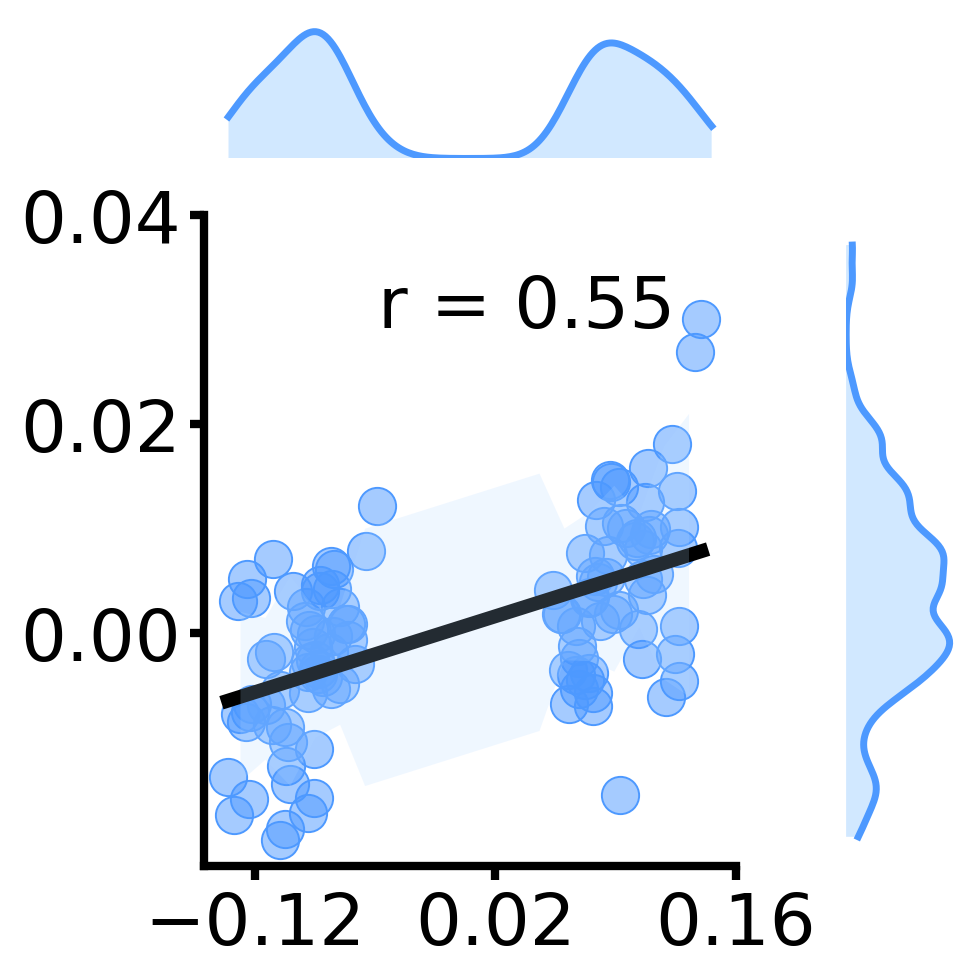

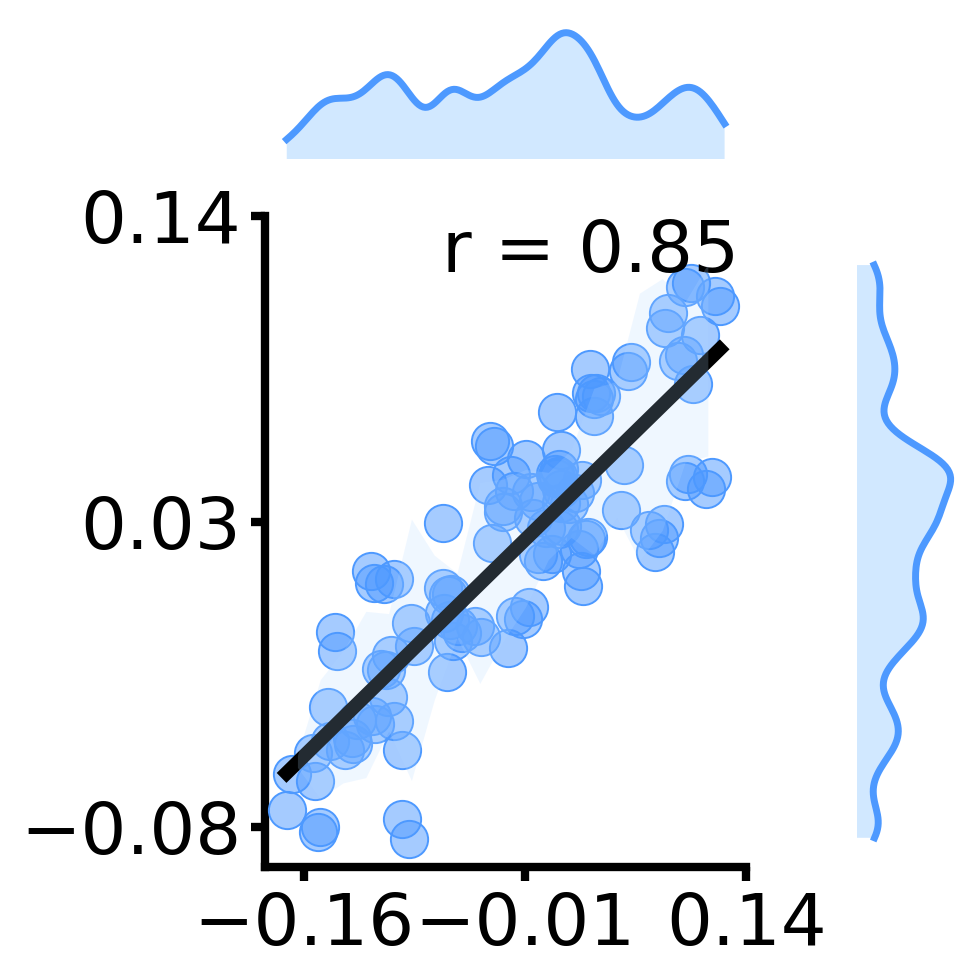

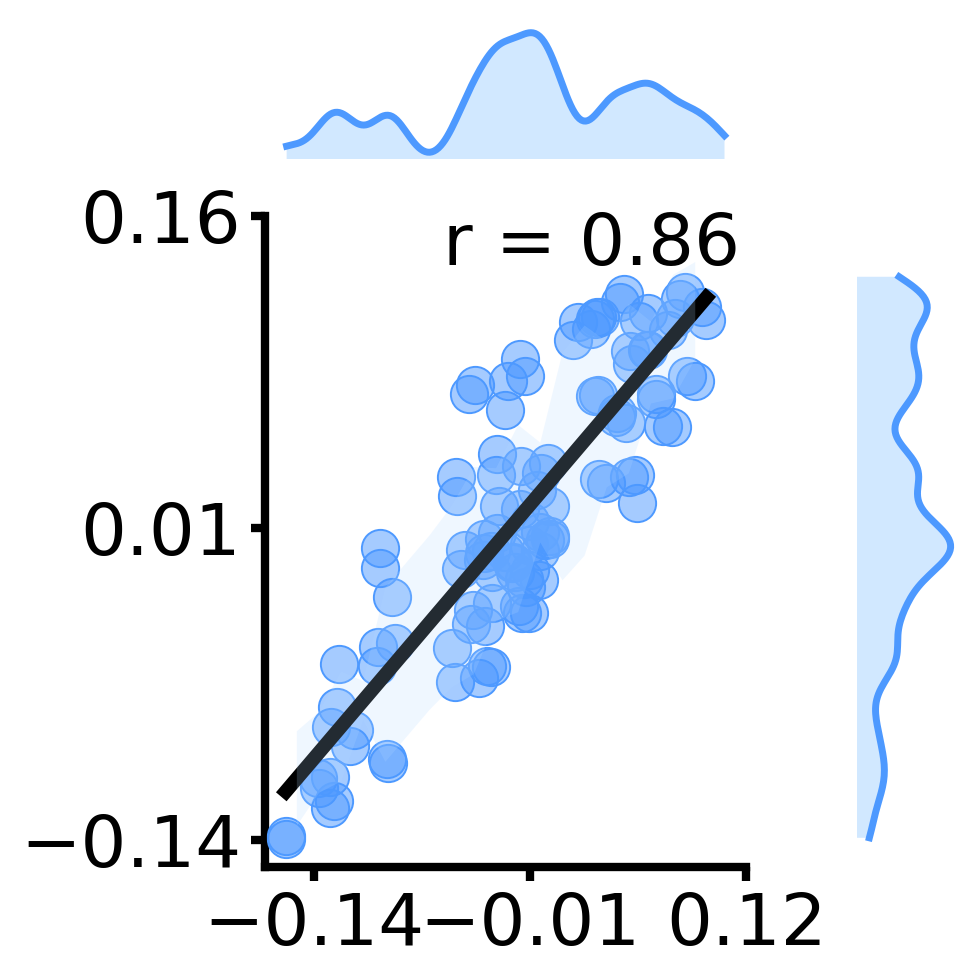

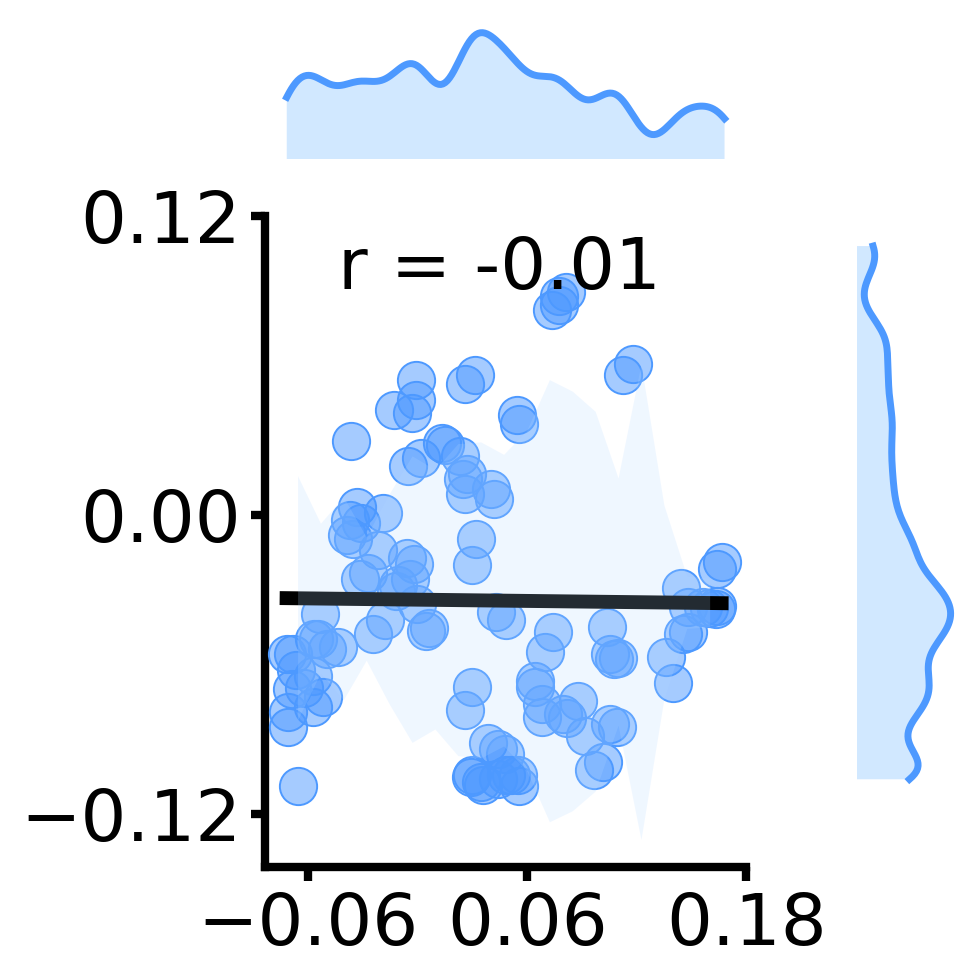

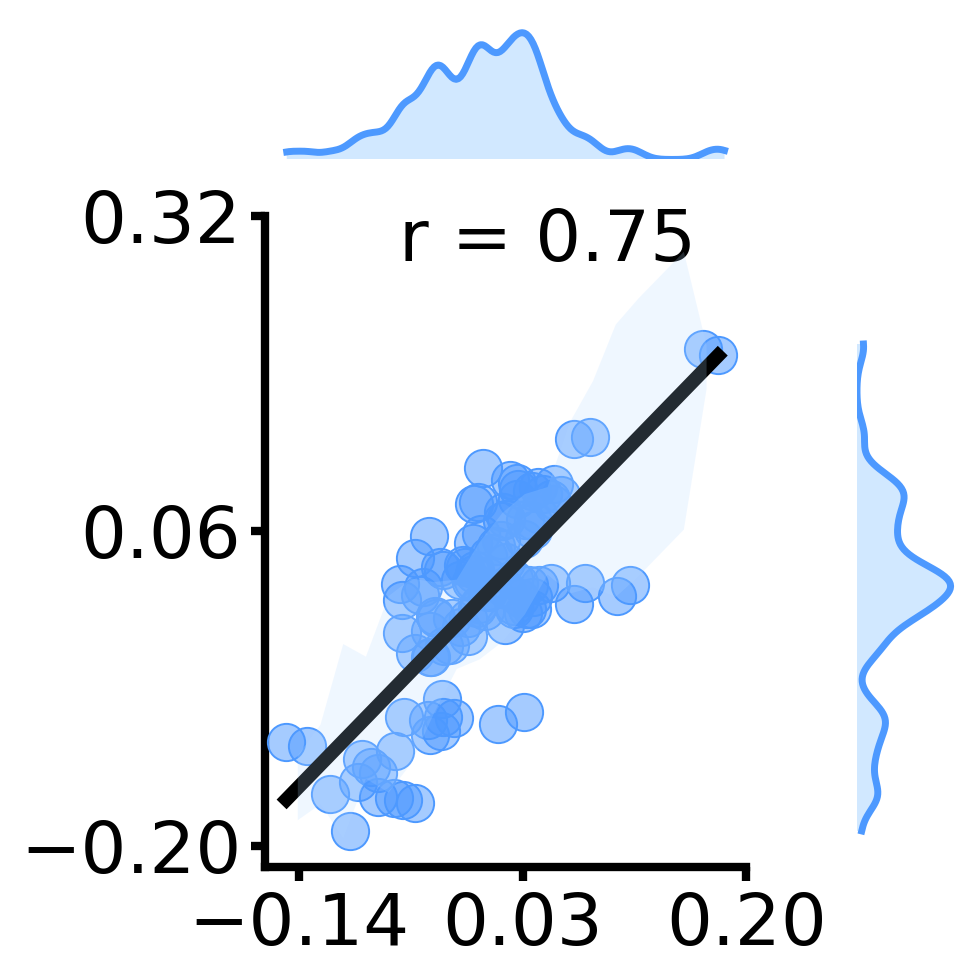

In [37]:
# displays SC loading FC loadings correlation

for mode in range(6):

    custom_join_plot(
        v[mode,nb_parcels:], 
        v[mode,:nb_parcels], 
        precision = 100, 
        std_fc = (0.70, 0.85, 1.00),
        fill_c = (0.70, 0.85, 1.00),          
        edge_c = (0.30, 0.60, 1.00),          
        scatter_fc = (0.30, 0.60, 1.00, 0.50), 
        scatter_ec = (0.30, 0.60, 1.00),
    )
    
    save_name = save_dir / f'Correlation_SC_FC_mode-{mode+1}.png'
    plt.savefig(save_name)
    save_name = save_dir / f'Correlation_SC_FC_mode-{mode+1}.svg'
    plt.savefig(save_name)


### Loading maps

Maps are displayed as follow:

- PC map is the left vector loadings
- FC map is the first half of the right vector loadings
- SC map is the second half of the right vector loadings

As PCA is defined only up to sign a normalisation factor is manually defined to enforce positive values in the cortex.

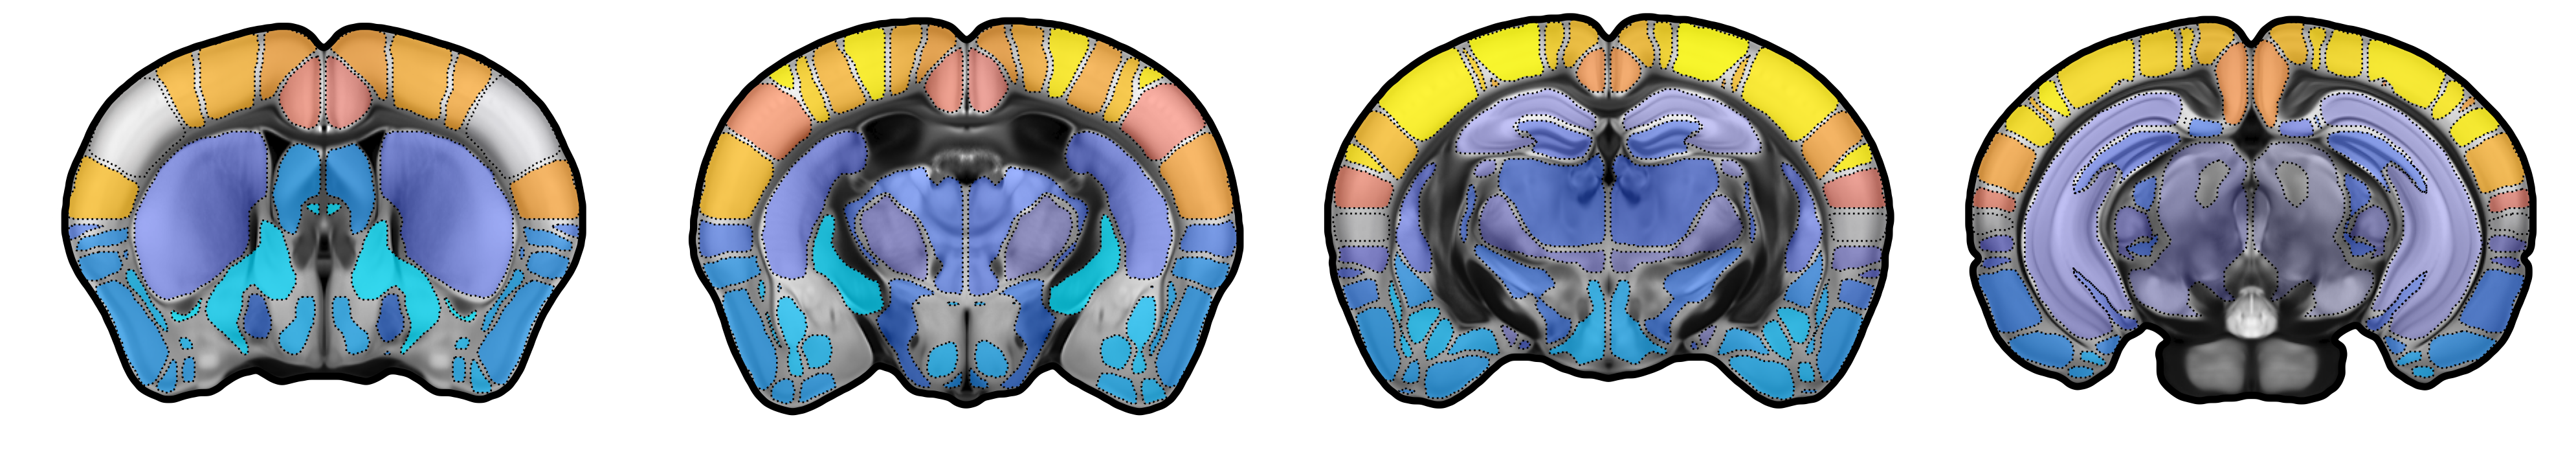

In [38]:
# Test single map

mode = 0

mode_img_lr = nib.Nifti1Image(
        from_vector_2_map(u[:,mode], parcel_scan).get_fdata(),
        affine = template_hr_img.affine
    )

cm = abs(mode_img_lr.get_fdata()).max()

mode_img = resample_img(
    mode_img_lr,
    target_affine=template_hr_img.affine,
    target_shape=template_hr_img.shape,
    interpolation='continuous',
    copy_header=True,
    force_resample=True
)

sign_factor = -np.sign(np.sign(u[:,mode]).sum())
if sign_factor == 0:
    sign_factor = 1

[X,Y,Z] = template_hr_img.get_fdata().shape

nb_lin = 1
nb_col = 4

# Mode Source

fig, ax = plt.subplots(nb_lin, nb_col, figsize = (nb_col*5, nb_lin*4), dpi=200, facecolor = 'w')

for i in range(4):

    # template
    
    a = template_hr_img.get_fdata()[i,:,:]
    mask = binary_fill_holes(a > 10)
    ax[i].imshow(a, cmap = 'Greys_r', vmin = vmin_allen, vmax = vmax_allen, alpha = mask.astype(float))

    # Axis map
        
    img_2_display = sign_factor*mode_img.get_fdata()[i,:,:]

    # transparency
    
    alpha = (abs(img_2_display)/cm).astype(float)

    ax[i].imshow(img_2_display, cmap = mymap, vmin = -cm, vmax = cm, alpha = 0.8*alpha)

    # contour of ROIs

    img_2_display = parcel_scan.get_fdata()[i,:,:]
    
    for level in np.unique(img_2_display)[1:]:
        ax[i].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [1], linestyles = ':')

    # ax[i].contour((mask > 0).astype('float'), levels = [0.5], colors = ['k'], linewidths = [2], linestyles = ':')
        
    ax[i].contour(gaussian_filter(1.*mask,2), levels = [0.5], colors = ['k'], linewidths = [4])

    ax[i].axis('off')

plt.tight_layout()

In [39]:
# normalisaiton factor to enforce positive values in the cortex
correction_factor = [1, 1, 1, -1, -1, -1]

for mode in tqdm(range(6)):
    
    mode_img_lr = nib.Nifti1Image(
        from_vector_2_map(u[:,mode], parcel_scan).get_fdata(),
        affine = template_hr_img.affine
    )

    cm = abs(mode_img_lr.get_fdata()).max()    
    # biggest patch wins the red
    sign_factor = -np.sign(np.sign(u[:,mode]).sum())
    # if both blue and red patches have the same size
    if sign_factor == 0:
        sign_factor = 1
    # Potential correction to compare with previous results (results is acurate to the sign)
    sign_factor = sign_factor*correction_factor[mode]
        
    mode_img = resample_img(
        mode_img_lr,
        target_affine=template_hr_img.affine,
        target_shape=template_hr_img.shape,
        interpolation='continuous',
        copy_header=True,
        force_resample=True
    )

    
    [X,Y,Z] = template_hr_img.get_fdata().shape
    
    nb_lin = 1
    nb_col = 4
    
    # Mode Source
    
    fig, ax = plt.subplots(nb_lin, nb_col, figsize = (nb_col*5, nb_lin*4), dpi=200, facecolor = 'w')
    
    for i in range(4):
    
        # template
        
        a = template_hr_img.get_fdata()[i,:,:]
        mask = binary_fill_holes(a > 10)
        ax[-1-i].imshow(a, cmap = 'Greys_r', vmin = vmin_allen, vmax = vmax_allen, alpha = mask.astype(float))
    
        # Axis map
            
        img_2_display = sign_factor*mode_img.get_fdata()[i,:,:]
    
        # transparency
        
        alpha = (abs(img_2_display)/cm).astype(float)
    
        ax[-1-i].imshow(img_2_display, cmap = mymap, vmin = -cm, vmax = cm, alpha = 0.8*alpha)
    
        # contour of ROIs
    
        img_2_display = parcel_scan.get_fdata()[i,:,:]
        
        for level in np.unique(img_2_display)[1:]:
            ax[-1-i].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [1], linestyles = ':')
    
        # ax[i].contour((mask > 0).astype('float'), levels = [0.5], colors = ['k'], linewidths = [2], linestyles = ':')
            
        ax[-1-i].contour(gaussian_filter(1.*mask,2), levels = [0.5], colors = ['k'], linewidths = [4])
    
        ax[-1-i].axis('off')
    
    plt.tight_layout()
        
    plt.suptitle(f'PC-source-{mode+1}', color = 'k', fontsize = 20)
    plt.tight_layout()
    
    plt.savefig(save_dir / f'mode-{mode}_PC.png')
    plt.savefig(save_dir / f'mode-{mode}_PC.svg')
    plt.close('all')
    
    # FC Target
    
    mode_img_lr = nib.Nifti1Image(
            from_vector_2_map(v[mode,:nb_parcels], parcel_scan).get_fdata(),
            affine = template_hr_img.affine
        )

    cm = abs(mode_img_lr.get_fdata()).max()
    
    mode_img = resample_img(
        mode_img_lr,
        target_affine=template_hr_img.affine,
        target_shape=template_hr_img.shape,
        interpolation='continuous',
        copy_header=True,
        force_resample=True
    )
        
    [X,Y,Z] = template_hr_img.get_fdata().shape
    
    nb_lin = 1
    nb_col = 4
    
    # Mode Source
    
    fig, ax = plt.subplots(nb_lin, nb_col, figsize = (nb_col*5, nb_lin*4), dpi=200, facecolor = 'w')
    
    for i in range(4):
    
        # template
        
        a = template_hr_img.get_fdata()[i,:,:]
        mask = binary_fill_holes(a > 10)
        ax[-1-i].imshow(a, cmap = 'Greys_r', vmin = vmin_allen, vmax = vmax_allen, alpha = mask.astype(float))
    
        # Axis map
            
        img_2_display = sign_factor*mode_img.get_fdata()[i,:,:]
    
        # transparency
        
        alpha = (abs(img_2_display)/cm).astype(float)
    
        ax[-1-i].imshow(img_2_display, cmap = mymap, vmin = -cm, vmax = cm, alpha = 0.8*alpha)
    
        # contour of ROIs
    
        img_2_display = parcel_scan.get_fdata()[i,:,:]
        
        for level in np.unique(img_2_display)[1:]:
            ax[-1-i].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [1], linestyles = ':')
    
        # ax[i].contour((mask > 0).astype('float'), levels = [0.5], colors = ['k'], linewidths = [2], linestyles = ':')
            
        ax[-1-i].contour(gaussian_filter(1.*mask,2), levels = [0.5], colors = ['k'], linewidths = [4])
    
        ax[-1-i].axis('off')
        
    plt.tight_layout()
        
    plt.suptitle(f'FC-target-{mode+1}', color = 'k', fontsize = 20)
    plt.tight_layout()
    
    plt.savefig(save_dir / f'mode-{mode}_FC.png')
    plt.savefig(save_dir / f'mode-{mode}_FC.svg')
    plt.close('all')    
    
    # SC Target
    
    mode_img_lr = nib.Nifti1Image(
            from_vector_2_map(v[mode,nb_parcels:], parcel_scan).get_fdata(),
            affine = template_hr_img.affine
        )

    cm = abs(mode_img_lr.get_fdata()).max()
    
    mode_img = resample_img(
        mode_img_lr,
        target_affine=template_hr_img.affine,
        target_shape=template_hr_img.shape,
        interpolation='continuous',
        copy_header=True,
        force_resample=True
    )
    
    [X,Y,Z] = template_hr_img.get_fdata().shape
    
    nb_lin = 1
    nb_col = 4
    
    # Mode Source
    
    fig, ax = plt.subplots(nb_lin, nb_col, figsize = (nb_col*5, nb_lin*4), dpi=200, facecolor = 'w')
    
    for i in range(4):
    
        # template
        
        a = template_hr_img.get_fdata()[i,:,:]
        mask = binary_fill_holes(a > 10)
        ax[-1-i].imshow(a, cmap = 'Greys_r', vmin = vmin_allen, vmax = vmax_allen, alpha = mask.astype(float))
    
        # Axis map
            
        img_2_display = sign_factor*mode_img.get_fdata()[i,:,:]
    
        # transparency
        
        alpha = (abs(img_2_display)/cm).astype(float)
    
        ax[-1-i].imshow(img_2_display, cmap = mymap, vmin = -cm, vmax = cm, alpha = 0.8*alpha)
    
        # contour of ROIs
    
        img_2_display = parcel_scan.get_fdata()[i,:,:]
        
        for level in np.unique(img_2_display)[1:]:
            ax[-1-i].contour(img_2_display==level, levels = [0.5], colors = ['k'], linewidths = [1], linestyles = ':')
    
        # ax[i].contour((mask > 0).astype('float'), levels = [0.5], colors = ['k'], linewidths = [2], linestyles = ':')
            
        ax[-1-i].contour(gaussian_filter(1.*mask,2), levels = [0.5], colors = ['k'], linewidths = [4])
    
        ax[-1-i].axis('off')
        
    plt.tight_layout()

    plt.suptitle(f'SC-target-{mode+1}', color = 'k', fontsize = 20)
    plt.tight_layout()
    
    plt.savefig(save_dir / f'mode-{mode}_SC.png')
    plt.savefig(save_dir / f'mode-{mode}_SC.svg')
    plt.close('all')    
    

100%|███████████████████████████████████████████| 6/6 [01:04<00:00, 10.77s/it]
